# High Garden Coffee — Análisis Estratégico de Mercado con Machine Learning

**Empresa:** High Garden Coffee (Exportadora internacional de café)  
**Objetivo:** Aprovechar datos de consumo doméstico de café (1990–2020) para identificar tendencias, proyectar rangos de precios futuros, descubrir información clave y generar ventaja competitiva.

**Datos utilizados:**
- 'coffee_db.parquet' — Consumo doméstico de café en tazas, 55 países, 30 temporadas (fuente: dataset proporcionado)
- 'arabica_precios.csv' — Precios globales anuales de café Arabica en US cents/lb (fuente: FMI vía FRED)
- 'robusta_precios.csv' — Precios globales anuales de café Robusta en US cents/lb (fuente: FMI vía FRED)

**Estructura del análisis:**
1. Carga y exploración de datos
2. Análisis exploratorio profundo (EDA)
3. Modelos de Machine Learning (Forecasting, Clustering, Detección de tendencias)
4. Integración consumo–precio y proyección de rangos de precios
5. Insights estratégicos y recomendaciones de negocio
6. Propuesta de integración con IA Generativa (Bonus)

## 1. Configuración del Entorno

Importación de todas las librerías que usaremos en el proyecto:

- **pandas / numpy** → Manipulación y cálculo con datos tabulares
- **matplotlib / seaborn / plotly** → Visualización de datos (estáticos e interactivos)
- **scikit-learn** → Algoritmos de Machine Learning (clustering, métricas)

In [137]:
# ============================================================
# LIBRERÍAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings

# Configuración general
warnings.filterwarnings('ignore')
sns.set_style('white')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print(" Librerías cargadas correctamente")

 Librerías cargadas correctamente


## 2. Carga de Datos

Carga de los 3 archivos:
- El dataset principal de consumo está en formato **Parquet**.
- Los precios están en CSV (valores separados por comas).

In [138]:
# ============================================================
# CARGA DE DATOS
# ============================================================

# Dataset principal: consumo doméstico de café por país y tipo
df_consumo = pd.read_parquet('../data/coffee_db.parquet')

# Precios históricos del café (fuente: FMI vía FRED)
df_arabica = pd.read_csv('../data/arabica_precios.csv')
df_robusta = pd.read_csv('../data/robusta_precios.csv')

print(f" Dataset de consumo: {df_consumo.shape[0]} países × {df_consumo.shape[1]} columnas")
print(f" Precios Arabica: {len(df_arabica)} años de datos")
print(f" Precios Robusta: {len(df_robusta)} años de datos")

 Dataset de consumo: 55 países × 33 columnas
 Precios Arabica: 34 años de datos
 Precios Robusta: 34 años de datos


## 3. Exploración Inicial

Antes de analizar, se necesita entender:
- ¿Qué columnas tenemos y qué significan?
- ¿Hay valores nulos o inconsistencias?
- ¿Cómo se ven los datos?

> **Nota sobre la temporada cafetera:** La ICO (International Coffee Organization) define el año cafetero de octubre a septiembre. Por ejemplo, "1990/91" cubre de octubre 1990 a septiembre 1991.

### 3.1 — RENOMBRAR COLUMNAS 

Se renombran las columnas de precios para mayor claridad y se convierten los centavos a dolares por libra


In [139]:
# Precios: los valores originales están en centavos de dólar por libra (US cents/lb)

df_arabica = df_arabica.rename(columns={
    'observation_date': 'Fecha',
    'PCOFFOTMUSDA': 'Precio_Arabica_centavos_por_libra'
})

df_robusta = df_robusta.rename(columns={
    'observation_date': 'Fecha',
    'PCOFFROBUSDA': 'Precio_Robusta_centavos_por_libra'
})

# Agrega una columna en dólares (más intuitivo para interpretar)
df_arabica['Precio_Arabica_USD_por_libra'] = df_arabica['Precio_Arabica_centavos_por_libra'] / 100
df_robusta['Precio_Robusta_USD_por_libra'] = df_robusta['Precio_Robusta_centavos_por_libra'] / 100

# Se extrae el año para poder cruzar con los datos de consumo
df_arabica['Año'] = pd.to_datetime(df_arabica['Fecha']).dt.year
df_robusta['Año'] = pd.to_datetime(df_robusta['Fecha']).dt.year

### 3.2 — Verificación de Calidad de los Datos

Un valor nulo (`NaN`) y un cero (`0`) son cosas diferentes para Python, pero no necesariamente para el negocio. Debemos preguntarnos: **¿los ceros representan "consumo real de cero tazas" o son datos faltantes disfrazados?**

Criterio de decisión:
- Si un país tiene ceros en los **primeros años** y luego aparece con valores altos → probablemente es dato faltante (el país no reportaba).
- Si un país tiene ceros en **todos los años** → probablemente nunca reportó datos y no aporta al análisis.
- Si un país tiene un cero **aislado** entre años con datos → podría ser un dato faltante puntual o un error.

In [140]:
# Columnas de años (temporadas)
year_columns = [col for col in df_consumo.columns if '/' in col]

print("=" * 70)
print("VERIFICACIÓN DE CALIDAD")
print("=" * 70)

# ¿Cada fila es un país único?
total_filas = df_consumo.shape[0]
paises_unicos = df_consumo['Country'].nunique()
print(f"\n Total de filas: {total_filas}")
print(f" Países únicos: {paises_unicos}")
if total_filas == paises_unicos:
    print("   Cada fila es un país único (no hay duplicados)")
else:
    print("   HAY DUPLICADOS — hay que investigar")

# Valores nulos reales (NaN)
nulos = df_consumo.isnull().sum().sum()
print(f"\n Valores NaN: {nulos}")

# Valores cero (posibles datos faltantes disfrazados)
print(f"\n ANÁLISIS DE CEROS (posibles datos faltantes):")
print("-" * 70)

for _, row in df_consumo.iterrows():
    zeros = sum(row[year_columns] == 0)
    if zeros > 0:
        # Encontrar cuáles años son cero
        zero_years = [col for col in year_columns if row[col] == 0]
        non_zero_years = [col for col in year_columns if row[col] > 0]
        
        if len(non_zero_years) == 0:
            status = " TODOS los años en cero → Sin datos útiles"
        elif zero_years[-1] < non_zero_years[0]:
            status = " Ceros al INICIO → Probable dato faltante (no reportaba)"
        else:
            status = " Ceros dispersos → Requiere revisión"
            
        print(f"  {row['Country']:40s} | {zeros:2d} ceros de 30 años | {status}")

print(f"\n Países SIN ningún cero: {total_filas - sum((df_consumo[year_columns] == 0).any(axis=1))}")

VERIFICACIÓN DE CALIDAD

 Total de filas: 55
 Países únicos: 55
   Cada fila es un país único (no hay duplicados)

 Valores NaN: 0

 ANÁLISIS DE CEROS (posibles datos faltantes):
----------------------------------------------------------------------
  Timor-Leste                              | 20 ceros de 30 años |  Ceros al INICIO → Probable dato faltante (no reportaba)
  Zambia                                   | 11 ceros de 30 años |  Ceros dispersos → Requiere revisión
  Equatorial Guinea                        | 30 ceros de 30 años |  TODOS los años en cero → Sin datos útiles
  Guyana                                   |  8 ceros de 30 años |  Ceros al INICIO → Probable dato faltante (no reportaba)
  Lao People's Democratic Republic         | 12 ceros de 30 años |  Ceros al INICIO → Probable dato faltante (no reportaba)
  Nepal                                    | 30 ceros de 30 años |  TODOS los años en cero → Sin datos útiles
  Yemen                                    | 13 ceros 

### 3.3 — Decisión sobre Tratamiento de Ceros

**Criterio:** Un cero en consumo nacional de café puede significar dos cosas:
1. **Dato faltante** → El país no reportaba datos en esos años
2. **Consumo real de cero** → Poco probable para un país que produce o consume café

**Regla de decisión:**
- Ceros al **inicio** de la serie (antes del primer dato real) → Son datos faltantes → Reemplazar por `NaN`
- Ceros al **final** de la serie (después del último dato real) → También probables datos faltantes → Reemplazar por `NaN`
- Ceros en **medio** de datos reales → Requeriría investigación caso por caso
- **Todos** los años en cero → País sin información útil → Eliminar del análisis

**¿Por qué NaN y no dejar ceros?** Porque `NaN` le dice a Python "no hay dato, ignóralo en los cálculos". Un cero en cambio entra en promedios, sumas y modelos como si fuera un valor real, distorsionando los resultados.

In [141]:
df_clean = df_consumo.copy()

# Eliminar países con todos los años en cero 
all_zero_mask = df_clean[year_columns].sum(axis=1) == 0
paises_eliminados = df_clean[all_zero_mask]['Country'].tolist()
df_clean = df_clean[~all_zero_mask].reset_index(drop=True)


print(f"\n Países eliminados (todos los años en cero): {paises_eliminados}")

# Reemplazar ceros al inicio y al final por NaN
ceros_inicio = 0
ceros_final = 0

for idx, row in df_clean.iterrows():
    values = row[year_columns].values.astype(float)
    non_zero_idx = np.where(values > 0)[0]
    
    if len(non_zero_idx) > 0:
        primer_real = non_zero_idx[0]
        ultimo_real = non_zero_idx[-1]
        
        for i in range(primer_real):
            df_clean.at[idx, year_columns[i]] = np.nan
            ceros_inicio += 1
        
        for i in range(ultimo_real + 1, len(year_columns)):
            if values[i] == 0:
                df_clean.at[idx, year_columns[i]] = np.nan
                ceros_final += 1

print(f"\n Ceros al inicio reemplazados por NaN: {ceros_inicio}")
print(f" Ceros al final reemplazados por NaN: {ceros_final}")
print(f"   Total de ceros convertidos a NaN: {ceros_inicio + ceros_final}")

nulos = df_clean[year_columns].isnull().sum().sum()
ceros = (df_clean[year_columns] == 0).sum().sum()

print(f"\n Dataset limpio:")
print(f"   Países: {df_clean.shape[0]}")
print(f"   Valores NaN (datos faltantes reconocidos): {nulos}")
print(f"   Ceros restantes: {ceros}")


 Países eliminados (todos los años en cero): ['Equatorial Guinea', 'Nepal']

 Ceros al inicio reemplazados por NaN: 53
 Ceros al final reemplazados por NaN: 11
   Total de ceros convertidos a NaN: 64

 Dataset limpio:
   Países: 53
   Valores NaN (datos faltantes reconocidos): 64
   Ceros restantes: 0


## 4. Transformación de Datos

### ¿Por qué transformar?

El dataset usado está en formato **ancho**: cada temporada es una columna. Es necesario pasarlo a formato **largo** para poder graficarlo y analizarlo con facilidad.

**Formato ancho (actual):**

| País | 1990/91 | 1991/92 | ... |
|---------|---------|---------|-----|
| Brazil  | 492M    | 510M    | ... |

**Formato largo (objetivo):**

| País | Año | Consumo_Anual_Domestico |
|---------|------|-------------|
| Brazil  | 1990 | 492M        |
| Brazil  | 1991 | 510M        |

Esto permite agrupar, filtrar y graficar por año, país o tipo de café con una sola línea de código.

In [142]:
# ============================================================
# 4.1 — TRANSFORMAR CONSUMO DE FORMATO ANCHO A LARGO
# ============================================================

df_consumo_pais = pd.melt(
    df_clean,
    id_vars=['Country', 'Coffee type'],
    value_vars=year_columns,
    var_name='Cosecha',
    value_name='Consumo_Anual_Domestico'
)

# Renombra las columnas que venían del dataset original
df_consumo_pais = df_consumo_pais.rename(columns={
    'Country': 'Pais',
    'Coffee type': 'Tipo_Cafe'
})

df_consumo_pais['Año_Inicio'] = df_consumo_pais['Cosecha'].str.split('/').str[0].astype(int)
df_consumo_pais['Año_Fin'] = df_consumo_pais['Año_Inicio'] + 1

# Ordena cronológicamente por país
df_consumo_pais = df_consumo_pais.sort_values(['Pais', 'Año_Inicio']).reset_index(drop=True)

print(f" Transformación completa")
print(f"   Formato anterior: {df_clean.shape[0]} filas × {df_clean.shape[1]} columnas")
print(f"   Formato nuevo:    {df_consumo_pais.shape[0]} filas × {df_consumo_pais.shape[1]} columnas")
print(f"   ({df_clean.shape[0]} países × {len(year_columns)} cosechas = {df_clean.shape[0] * len(year_columns)} registros)")
print(f"\n   Registros con dato real: {df_consumo_pais['Consumo_Anual_Domestico'].notna().sum()}")
print(f"   Registros NaN (faltantes): {df_consumo_pais['Consumo_Anual_Domestico'].isna().sum()}")
print(f"\n Vista previa:")
df_consumo_pais.head(5)

 Transformación completa
   Formato anterior: 53 filas × 33 columnas
   Formato nuevo:    1590 filas × 6 columnas
   (53 países × 30 cosechas = 1590 registros)

   Registros con dato real: 1526
   Registros NaN (faltantes): 64

 Vista previa:


,Pais,Tipo_Cafe,Cosecha,Consumo_Anual_Domestico,Año_Inicio,Año_Fin
0,Angola,Robusta/Arabica,1990/91,1200000.0,1990,1991
1,Angola,Robusta/Arabica,1991/92,1800000.0,1991,1992
2,Angola,Robusta/Arabica,1992/93,2100000.0,1992,1993
3,Angola,Robusta/Arabica,1993/94,1200000.0,1993,1994
4,Angola,Robusta/Arabica,1994/95,1500000.0,1994,1995


In [143]:
# ============================================================
# 4.2 — PREPARAR DATASET UNIFICADO DE PRECIOS
# ============================================================
df_precios = pd.merge(
    df_arabica[['Año', 'Precio_Arabica_USD_por_libra']],
    df_robusta[['Año', 'Precio_Robusta_USD_por_libra']],
    on='Año',
    how='outer'
).sort_values('Año').reset_index(drop=True)

print(f" Dataset de precios unificado")
print(f"   Rango: {df_precios['Año'].min()} — {df_precios['Año'].max()}")
print(f"   Años con datos: {len(df_precios)}")
print(f"\n Vista previa:")
df_precios.head(1)

 Dataset de precios unificado
   Rango: 1992 — 2025
   Años con datos: 34

 Vista previa:


,Año,Precio_Arabica_USD_por_libra,Precio_Robusta_USD_por_libra
0,1992,0.617374,0.42224


## 5. Análisis Exploratorio de Datos (EDA)

### 5.1 — Panorama Global: ¿El mercado del café está creciendo?

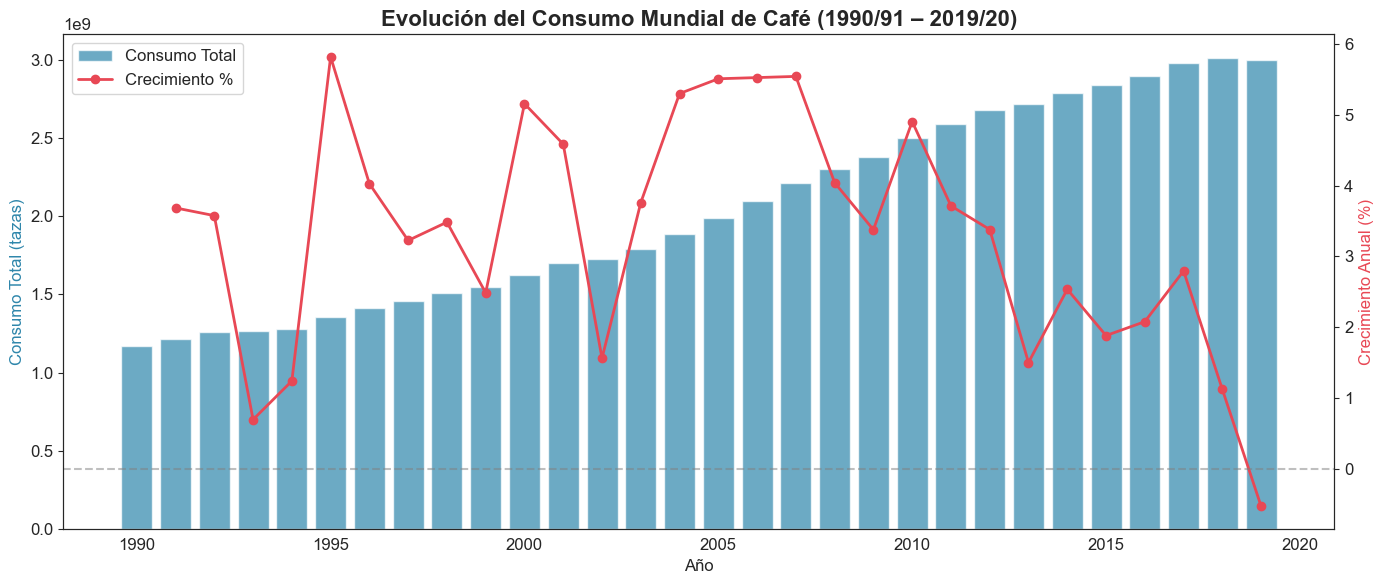


 INSIGHT: El consumo mundial pasó de 1,171M a 2,999M de tazas
   Crecimiento total (1990/91-2019/20): 156.2%
   Crecimiento promedio anual: 3.3%


In [144]:
# ============================================================
# 5.1 — EVOLUCIÓN DEL CONSUMO MUNDIAL DE CAFÉ
# ============================================================

# Agrupa el consumo total por año (sumamos todos los países)
consumo_mundial = df_consumo_pais.groupby('Año_Inicio')['Consumo_Anual_Domestico'].sum().reset_index()
consumo_mundial.columns = ['Año', 'Consumo_Total']

# Calcula el crecimiento porcentual año a año
consumo_mundial['Crecimiento_Pct'] = consumo_mundial['Consumo_Total'].pct_change() * 100

# Gráfico
fig, ax1 = plt.subplots(figsize=(14, 6))

# Barras de consumo total
bars = ax1.bar(consumo_mundial['Año'], consumo_mundial['Consumo_Total'], 
               color='#2E86AB', alpha=0.7, label='Consumo Total')

ax1.set_xlabel('Año')
ax1.set_ylabel('Consumo Total (tazas)', color='#2E86AB')
ax1.set_title('Evolución del Consumo Mundial de Café (1990/91 – 2019/20)', fontsize=16, fontweight='bold')

# Línea de crecimiento porcentual en eje secundario
ax2 = ax1.twinx()
ax2.plot(consumo_mundial['Año'], consumo_mundial['Crecimiento_Pct'], 
         color='#E84855', marker='o', linewidth=2, label='Crecimiento %')
ax2.set_ylabel('Crecimiento Anual (%)', color='#E84855')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

# Insight numérico
inicio = consumo_mundial.iloc[0]['Consumo_Total']
fin = consumo_mundial.iloc[-1]['Consumo_Total']
crecimiento_total = ((fin - inicio) / inicio) * 100
print(f"\n INSIGHT: El consumo mundial pasó de {inicio/1e6:,.0f}M a {fin/1e6:,.0f}M de tazas")
print(f"   Crecimiento total (1990/91-2019/20): {crecimiento_total:.1f}%")
print(f"   Crecimiento promedio anual: {consumo_mundial['Crecimiento_Pct'].mean():.1f}%")

### 5.2 — ¿Quiénes dominan el mercado? Los Top 10 consumidores

Para una exportadora es crucial saber quiénes son los mayores consumidores y qué tan concentrado está el mercado. Si pocos países concentran la mayoría del consumo, el riesgo de dependencia es alto.

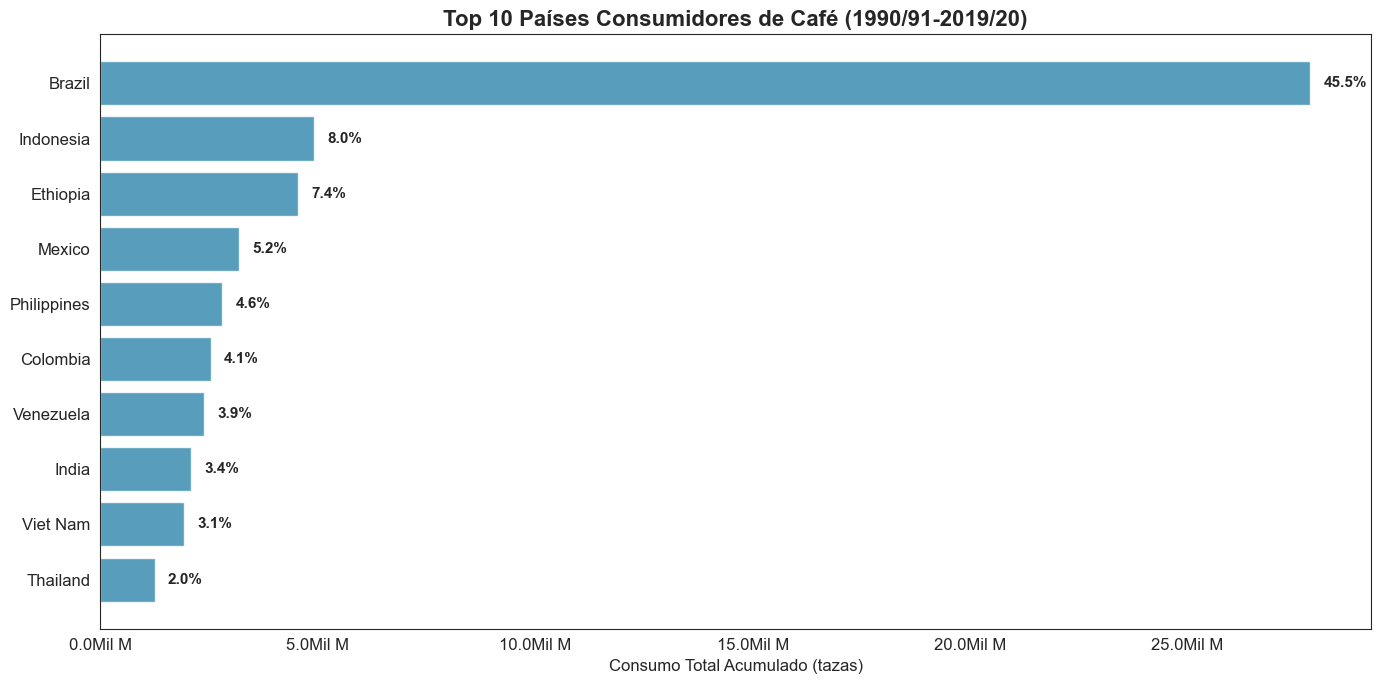


 INSIGHTS:
   • Brazil concentra el 45.5% del consumo mundial
   • Los Top 5 concentran el 70.7%
   • Los Top 10 concentran el 87.4%
   • Los otros 43 países solo representan el 12.6%


In [145]:
# ============================================================
# 5.2 — TOP 10 PAÍSES CONSUMIDORES
# ============================================================

# Consumo total acumulado por país (suma de todas las cosechas)
consumo_por_pais = df_consumo_pais.groupby('Pais')['Consumo_Anual_Domestico'].sum().reset_index()
consumo_por_pais.columns = ['Pais', 'Consumo_Total']
consumo_por_pais = consumo_por_pais.sort_values('Consumo_Total', ascending=False).reset_index(drop=True)

# Calcula el porcentaje del total mundial
total_mundial = consumo_por_pais['Consumo_Total'].sum()
consumo_por_pais['Porcentaje'] = (consumo_por_pais['Consumo_Total'] / total_mundial) * 100
consumo_por_pais['Porcentaje_Acumulado'] = consumo_por_pais['Porcentaje'].cumsum()

# Top 10
top10 = consumo_por_pais.head(10)

# Gráfico
fig, ax1 = plt.subplots(figsize=(14, 7))

bars = ax1.barh(top10['Pais'][::-1], top10['Consumo_Total'][::-1], color='#2E86AB', alpha=0.8)

# Agregar porcentaje al lado de cada barra
for bar, pct in zip(bars, top10['Porcentaje'][::-1]):
    ax1.text(bar.get_width() + total_mundial * 0.005, bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', va='center', fontsize=11, fontweight='bold')

ax1.set_xlabel('Consumo Total Acumulado (tazas)')
ax1.set_title('Top 10 Países Consumidores de Café (1990/91-2019/20)', fontsize=16, fontweight='bold')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e9:.1f}Mil M'))

plt.tight_layout()
plt.show()

# Insights
print(f"\n INSIGHTS:")
print(f"   • {top10.iloc[0]['Pais']} concentra el {top10.iloc[0]['Porcentaje']:.1f}% del consumo mundial")
print(f"   • Los Top 5 concentran el {consumo_por_pais.head(5)['Porcentaje'].sum():.1f}%")
print(f"   • Los Top 10 concentran el {top10['Porcentaje'].sum():.1f}%")
print(f"   • Los otros {len(consumo_por_pais) - 10} países solo representan el {100 - top10['Porcentaje'].sum():.1f}%")

### 5.3 — ¿Qué tipo de café domina el mercado?

Arabica y Robusta tienen perfiles de precio y sabor muy diferentes. Saber cuál está creciendo más ayuda a High Garden Coffee a decidir en qué tipo de café enfocar su estrategia de exportación.

Para medir el crecimiento usamos el **CAGR** (Compound Annual Growth Rate o Tasa de Crecimiento Anual Compuesta). Esta métrica toma el valor inicial y final de una serie, y calcula a qué ritmo constante tendría que haber crecido cada año para llegar del primero al último. Es útil porque ignora las subidas y bajadas intermedias y da una sola cifra comparable entre tipos de café o países.

**Fórmula:** $$CAGR = \left(\frac{Valor_{final}}{Valor_{inicial}}\right)^{\frac{1}{años}} - 1$$

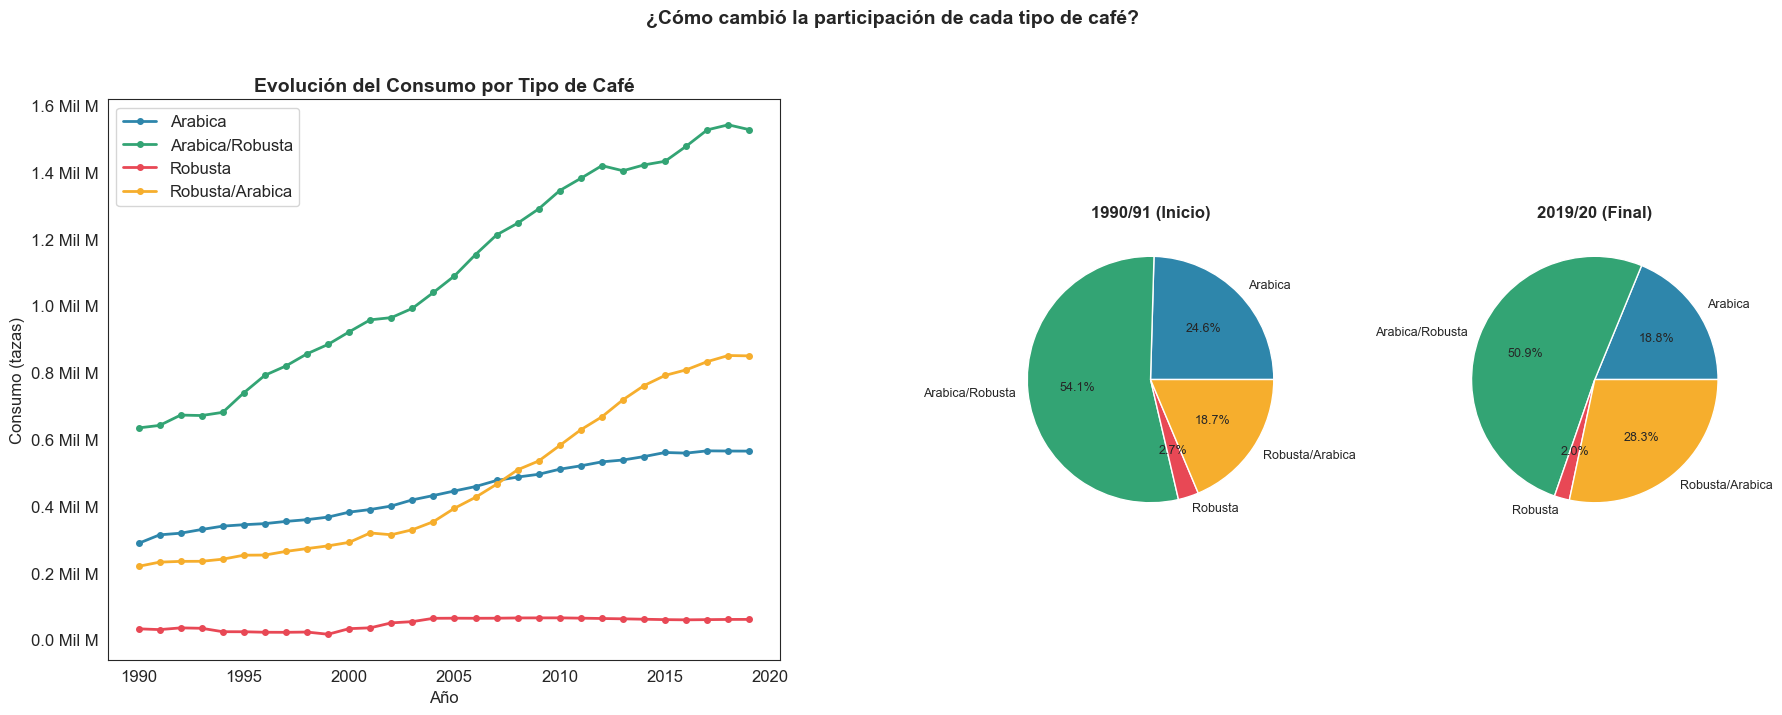


 INSIGHTS:
   • Arabica:  creció 96.1% total | CAGR: 2.3% anual
   • Arabica/Robusta:  creció 141.1% total | CAGR: 3.1% anual
   • Robusta:  creció 89.9% total | CAGR: 2.2% anual
   • Robusta/Arabica:  creció 288.4% total | CAGR: 4.8% anual


In [146]:
# ============================================================
# 5.3 — CONSUMO POR TIPO DE CAFÉ A LO LARGO DEL TIEMPO
# ============================================================

# Agrupa por año y tipo de café
consumo_tipo = df_consumo_pais.groupby(['Año_Inicio', 'Tipo_Cafe'])['Consumo_Anual_Domestico'].sum().reset_index()
consumo_tipo.columns = ['Año', 'Tipo_Cafe', 'Consumo']

# Colores por tipo
colores = {'Arabica': '#2E86AB', 'Robusta': '#E84855', 
           'Robusta/Arabica': '#F6AE2D', 'Arabica/Robusta': '#33A474'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Líneas de evolución
for tipo in consumo_tipo['Tipo_Cafe'].unique():
    data = consumo_tipo[consumo_tipo['Tipo_Cafe'] == tipo]
    ax1.plot(data['Año'], data['Consumo'], marker='o', linewidth=2, 
             label=tipo, color=colores.get(tipo, 'gray'), markersize=4)

ax1.set_xlabel('Año')
ax1.set_ylabel('Consumo (tazas)')
ax1.set_title('Evolución del Consumo por Tipo de Café', fontsize=14, fontweight='bold')
ax1.legend()
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e9:.1f} Mil M'))

# Gráfico 2: Participación de mercado (último año vs primer año)
for i, year_label in enumerate(['1990/91 (Inicio)', '2019/20 (Final)']):
    year_val = 1990 if i == 0 else 2019
    data_year = consumo_tipo[consumo_tipo['Año'] == year_val]
    colors_list = [colores.get(t, 'gray') for t in data_year['Tipo_Cafe']]
    
    ax2_sub = fig.add_subplot(1, 4, i + 3)
    wedges, texts, autotexts = ax2_sub.pie(
        data_year['Consumo'], labels=data_year['Tipo_Cafe'],
        autopct='%1.1f%%', colors=colors_list, textprops={'fontsize': 9}
    )
    ax2_sub.set_title(year_label, fontsize=12, fontweight='bold')

# Elimina el ax2 original que ya no usamos
ax2.remove()

plt.suptitle('¿Cómo cambió la participación de cada tipo de café?', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Insights
print(f"\n INSIGHTS:")
for tipo in consumo_tipo['Tipo_Cafe'].unique():
    data_tipo = consumo_tipo[consumo_tipo['Tipo_Cafe'] == tipo]
    inicio = data_tipo[data_tipo['Año'] == 1990]['Consumo'].values
    fin = data_tipo[data_tipo['Año'] == 2019]['Consumo'].values
    if len(inicio) > 0 and len(fin) > 0 and inicio[0] > 0:
        cambio = ((fin[0] - inicio[0]) / inicio[0]) * 100
        n_años = 29
        cagr = ((fin[0] / inicio[0]) ** (1 / n_años) - 1) * 100
        direccion = " creció" if cambio > 0 else " cayó"
        print(f"   • {tipo}: {direccion} {abs(cambio):.1f}% total | CAGR: {cagr:.1f}% anual")

### 5.4 — Mercados Emergentes vs Mercados en Declive

Para una exportadora, es tan importante saber quién consume más como saber **quién está creciendo más rápido**. Un país pequeño con alto crecimiento puede ser más rentable a futuro que un mercado grande pero estancado.

Se usa el CAGR para identificar los mercados con mayor potencial y los que están perdiendo fuerza.

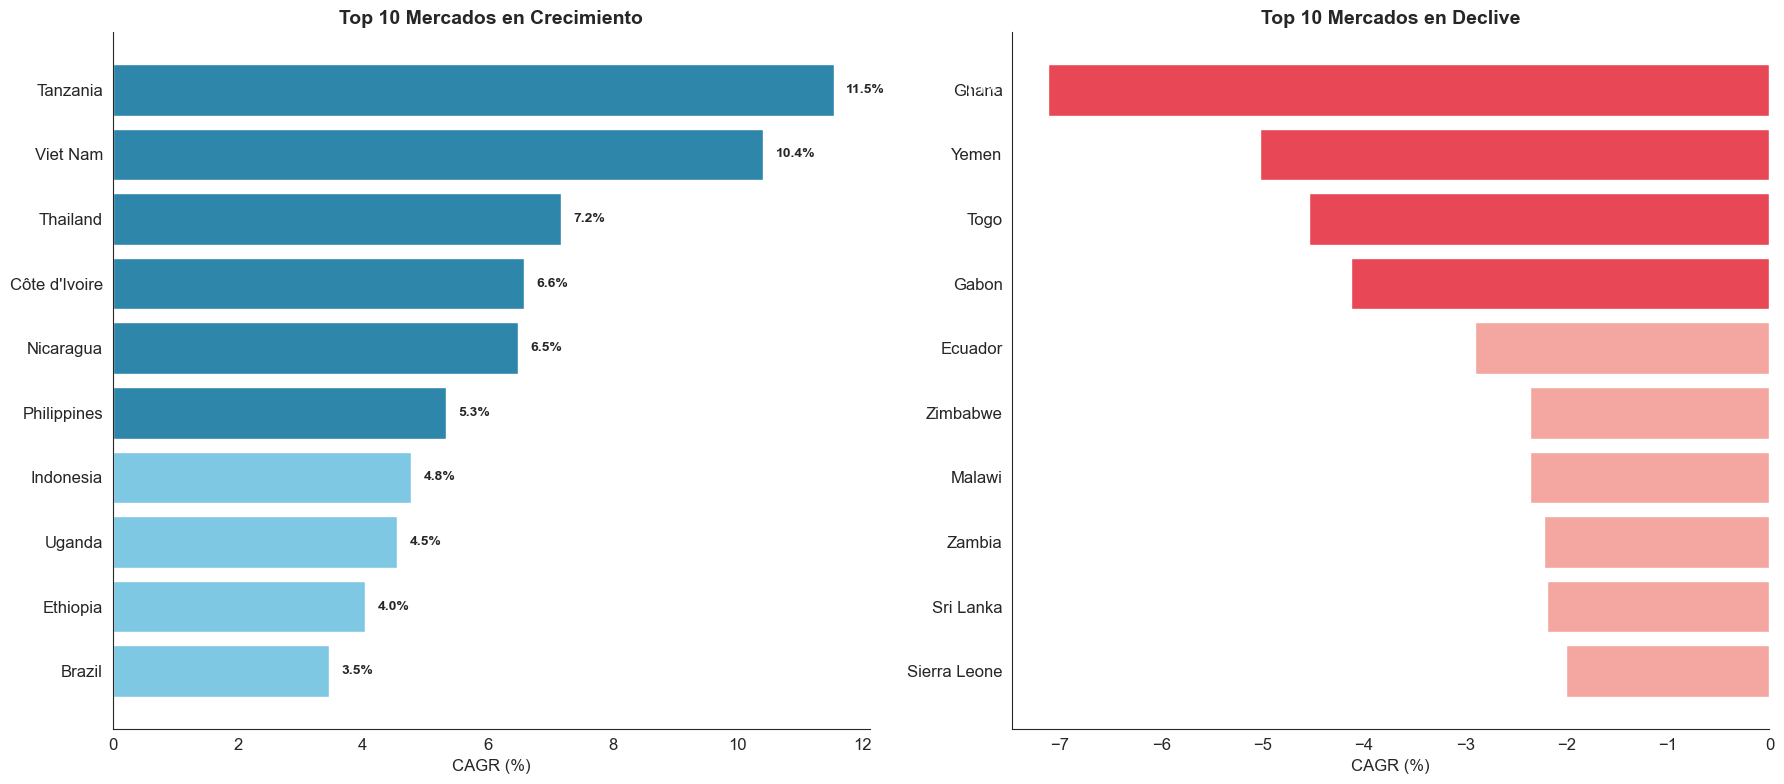


 INSIGHTS:
    Mayor crecimiento: Tanzania con CAGR de 11.5% anual
    Mayor declive: Ghana con CAGR de -7.1% anual

   Países con crecimiento > 5% anual: 6
   Países con crecimiento negativo: 16
   Países estables (0-5% anual): 31


In [147]:
# ============================================================
# 5.4 — MERCADOS EMERGENTES VS MERCADOS EN DECLIVE
# ============================================================

# Calcular CAGR por país
cagr_pais = []

for _, row in df_clean.iterrows():
    pais = row['Country']
    tipo = row['Coffee type']
    valores = row[year_columns].values.astype(float)
    
    # Buscar primer y último valor real (no NaN)
    valid_idx = np.where(~np.isnan(valores) & (valores > 0))[0]
    
    if len(valid_idx) >= 2:
        inicio = valores[valid_idx[0]]
        fin = valores[valid_idx[-1]]
        n_años = valid_idx[-1] - valid_idx[0]
        
        if n_años > 0 and inicio > 0:
            cagr = ((fin / inicio) ** (1 / n_años) - 1) * 100
            cambio_total = ((fin - inicio) / inicio) * 100
            cagr_pais.append({
                'Pais': pais,
                'Tipo_Cafe': tipo,
                'Consumo_Inicio': inicio,
                'Consumo_Fin': fin,
                'Años_Datos': n_años,
                'CAGR': cagr,
                'Cambio_Total_Pct': cambio_total
            })

df_cagr = pd.DataFrame(cagr_pais).sort_values('CAGR', ascending=False).reset_index(drop=True)

top_crecimiento = df_cagr.head(10)
top_declive = df_cagr[df_cagr['CAGR'] < 0].sort_values('CAGR').head(10)

# --- GRÁFICO ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Mercados emergentes
colors_crec = ['#2E86AB' if c > 5 else '#7EC8E3' for c in top_crecimiento['CAGR']]
bars1 = ax1.barh(top_crecimiento['Pais'][::-1], top_crecimiento['CAGR'][::-1], 
                  color=colors_crec[::-1])
for bar, val in zip(bars1, top_crecimiento['CAGR'][::-1]):
    ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax1.set_xlabel('CAGR (%)')
ax1.set_title('Top 10 Mercados en Crecimiento', fontsize=14, fontweight='bold')

# Mercados en declive
colors_decl = ['#E84855' if c < -3 else '#F4A6A0' for c in top_declive['CAGR']]
bars2 = ax2.barh(top_declive['Pais'][::-1], top_declive['CAGR'][::-1],
                  color=colors_decl[::-1])
for bar, val in zip(bars2, top_declive['CAGR'][::-1]):
    ax2.text(val - 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', ha='right', fontsize=10, 
             fontweight='bold', color='white')
ax2.set_xlabel('CAGR (%)')
ax2.set_title('Top 10 Mercados en Declive', fontsize=14, fontweight='bold')
# Quitar bordes innecesarios
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Insights
print(f"\n INSIGHTS:")
print(f"    Mayor crecimiento: {top_crecimiento.iloc[0]['Pais']} "
      f"con CAGR de {top_crecimiento.iloc[0]['CAGR']:.1f}% anual")
print(f"    Mayor declive: {top_declive.iloc[0]['Pais']} "
      f"con CAGR de {top_declive.iloc[0]['CAGR']:.1f}% anual")
print(f"\n   Países con crecimiento > 5% anual: {len(df_cagr[df_cagr['CAGR'] > 5])}")
print(f"   Países con crecimiento negativo: {len(df_cagr[df_cagr['CAGR'] < 0])}")
print(f"   Países estables (0-5% anual): {len(df_cagr[(df_cagr['CAGR'] >= 0) & (df_cagr['CAGR'] <= 5)])}")

### 5.5 — Evolución Histórica de Precios: Arabica vs Robusta

Los precios del café verde fluctúan según oferta, demanda, clima y factores geopolíticos. Entender cómo se han comportado históricamente es clave antes de intentar proyectarlos al futuro.

Los precios están en **USD por libra** de café verde (fuente: FMI). Se limita el análisis hasta 2020 para mantener coherencia con los datos de consumo.

Se presentan dos gráficos:
- **Arriba:** Precio de cada tipo de café a lo largo del tiempo
- **Abajo:** Spread (diferencia de precio entre Arabica y Robusta). Un spread alto significa que Arabica es mucho más caro que Robusta; un spread bajo significa que sus precios se acercan.

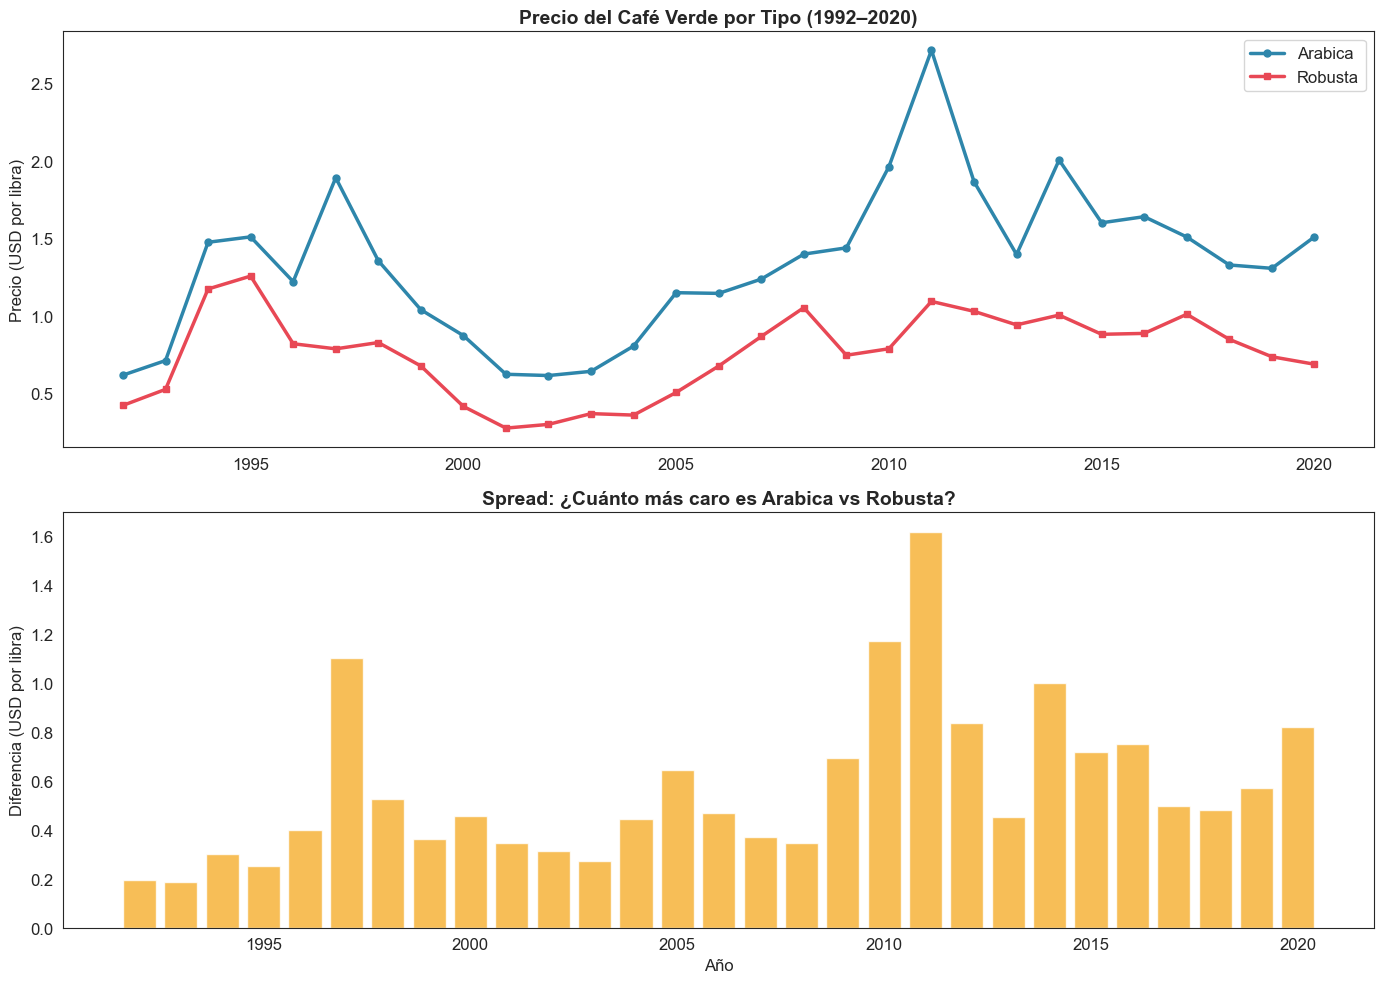


 INSIGHTS:
   Precio Arabica en 2020: $1.51 USD/lb
   Precio Robusta en 2020: $0.69 USD/lb
   Spread en 2020: $0.82 USD/lb

   CAGR precios Arabica (1992–2020): 3.2% anual
   CAGR precios Robusta (1992–2020): 1.8% anual


In [148]:
# ============================================================
# 5.5 — EVOLUCIÓN HISTÓRICA DE PRECIOS (hasta 2020)
# ============================================================

# Filtra hasta 2020 para ser coherentes con los datos de consumo
df_arabica_filtrado = df_arabica[df_arabica['Año'] <= 2020]
df_robusta_filtrado = df_robusta[df_robusta['Año'] <= 2020]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico 1: Precios absolutos
ax1.plot(df_arabica_filtrado['Año'], df_arabica_filtrado['Precio_Arabica_USD_por_libra'], 
         color='#2E86AB', linewidth=2.5, marker='o', markersize=5, label='Arabica')
ax1.plot(df_robusta_filtrado['Año'], df_robusta_filtrado['Precio_Robusta_USD_por_libra'], 
         color='#E84855', linewidth=2.5, marker='s', markersize=5, label='Robusta')

ax1.set_ylabel('Precio (USD por libra)')
ax1.set_title('Precio del Café Verde por Tipo (1992–2020)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=12)

# Gráfico 2: Spread (diferencia entre Arabica y Robusta)
df_precios = pd.merge(
    df_arabica_filtrado[['Año', 'Precio_Arabica_USD_por_libra']],
    df_robusta_filtrado[['Año', 'Precio_Robusta_USD_por_libra']],
    on='Año', how='inner'
)
df_precios['Spread'] = df_precios['Precio_Arabica_USD_por_libra'] - df_precios['Precio_Robusta_USD_por_libra']

ax2.bar(df_precios['Año'], df_precios['Spread'], color='#F6AE2D', alpha=0.8)
ax2.set_xlabel('Año')
ax2.set_ylabel('Diferencia (USD por libra)')
ax2.set_title('Spread: ¿Cuánto más caro es Arabica vs Robusta?', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Insights
precio_arabica_2020 = df_arabica_filtrado[df_arabica_filtrado['Año'] == 2020]['Precio_Arabica_USD_por_libra'].values[0]
precio_robusta_2020 = df_robusta_filtrado[df_robusta_filtrado['Año'] == 2020]['Precio_Robusta_USD_por_libra'].values[0]
spread_2020 = precio_arabica_2020 - precio_robusta_2020

precio_arabica_inicio = df_arabica_filtrado['Precio_Arabica_USD_por_libra'].iloc[0]
precio_robusta_inicio = df_robusta_filtrado['Precio_Robusta_USD_por_libra'].iloc[0]
n_años = len(df_arabica_filtrado) - 1

cagr_arabica = ((precio_arabica_2020 / precio_arabica_inicio) ** (1 / n_años) - 1) * 100
cagr_robusta = ((precio_robusta_2020 / precio_robusta_inicio) ** (1 / n_años) - 1) * 100

print(f"\n INSIGHTS:")
print(f"   Precio Arabica en 2020: ${precio_arabica_2020:.2f} USD/lb")
print(f"   Precio Robusta en 2020: ${precio_robusta_2020:.2f} USD/lb")
print(f"   Spread en 2020: ${spread_2020:.2f} USD/lb")
print(f"\n   CAGR precios Arabica (1992–2020): {cagr_arabica:.1f}% anual")
print(f"   CAGR precios Robusta (1992–2020): {cagr_robusta:.1f}% anual")

### 5.6 — ¿Existe relación entre el consumo mundial y los precios?

Esta es la pregunta más importante para poder proyectar precios futuros. Si el consumo (demanda) tiene correlación con los precios, entonces nuestras predicciones de consumo nos permiten inferir hacia dónde van los precios.

Para medir esta relación se hizo uso de la **correlación de Pearson**, que va de -1 a 1:
- **Cerca de 1:** cuando uno sube, el otro también sube
- **Cerca de -1:** cuando uno sube, el otro baja
- **Cerca de 0:** no hay relación clara

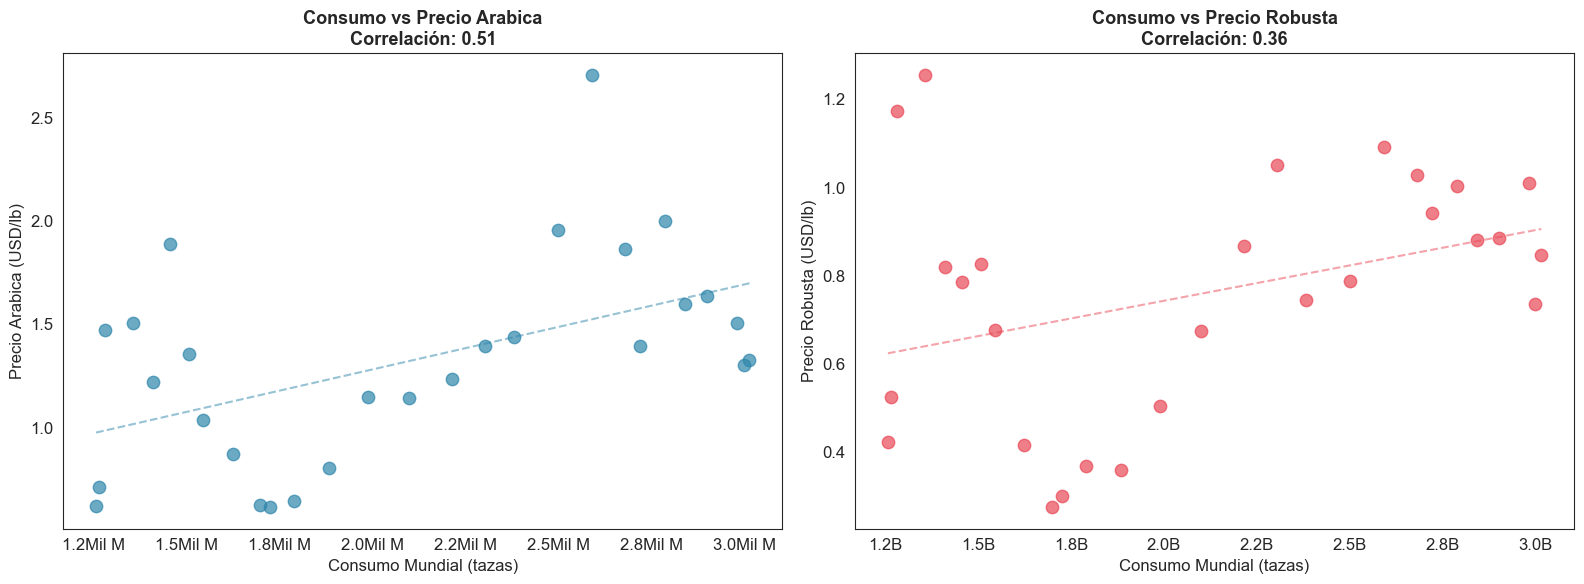


 INSIGHTS:
   Correlación Consumo ↔ Precio Arabica: 0.51
   Correlación Consumo ↔ Precio Robusta: 0.36

    Arabica: correlación moderada (0.51).
      El consumo tiene influencia sobre el precio.

    Robusta: correlación débil (0.36).
      El precio depende más de otros factores (clima, especulación, políticas).

   Conclusión: las proyecciones de precio serán más confiables para Arabica
   que para Robusta. En ambos casos, el consumo es solo uno de varios factores
   que influyen en el precio, por lo que las proyecciones se presentarán como
   rangos (optimista/pesimista), no como valores exactos.


In [149]:
# ============================================================
# 5.6 — RELACIÓN CONSUMO vs PRECIOS
# ============================================================

# Crea el dataset combinado (consumo global + precios) solo para años en común
consumo_mundial = df_consumo_pais.groupby('Año_Inicio')['Consumo_Anual_Domestico'].sum().reset_index()
consumo_mundial.columns = ['Año', 'Consumo_Total']

df_combinado = pd.merge(consumo_mundial, df_precios, on='Año', how='inner')

# Correlaciones
corr_arabica = df_combinado['Consumo_Total'].corr(df_combinado['Precio_Arabica_USD_por_libra'])
corr_robusta = df_combinado['Consumo_Total'].corr(df_combinado['Precio_Robusta_USD_por_libra'])

# --- GRÁFICO ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Consumo vs Precio Arabica
ax1.scatter(df_combinado['Consumo_Total'], df_combinado['Precio_Arabica_USD_por_libra'], 
            color='#2E86AB', s=80, alpha=0.7)
# Línea de tendencia
z1 = np.polyfit(df_combinado['Consumo_Total'], df_combinado['Precio_Arabica_USD_por_libra'], 1)
p1 = np.poly1d(z1)
x_line = np.linspace(df_combinado['Consumo_Total'].min(), df_combinado['Consumo_Total'].max(), 100)
ax1.plot(x_line, p1(x_line), color='#2E86AB', linestyle='--', alpha=0.5)

ax1.set_xlabel('Consumo Mundial (tazas)')
ax1.set_ylabel('Precio Arabica (USD/lb)')
ax1.set_title(f'Consumo vs Precio Arabica\nCorrelación: {corr_arabica:.2f}', 
              fontsize=13, fontweight='bold')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e9:.1f}Mil M'))

# Consumo vs Precio Robusta
ax2.scatter(df_combinado['Consumo_Total'], df_combinado['Precio_Robusta_USD_por_libra'], 
            color='#E84855', s=80, alpha=0.7)
z2 = np.polyfit(df_combinado['Consumo_Total'], df_combinado['Precio_Robusta_USD_por_libra'], 1)
p2 = np.poly1d(z2)
ax2.plot(x_line, p2(x_line), color='#E84855', linestyle='--', alpha=0.5)

ax2.set_xlabel('Consumo Mundial (tazas)')
ax2.set_ylabel('Precio Robusta (USD/lb)')
ax2.set_title(f'Consumo vs Precio Robusta\nCorrelación: {corr_robusta:.2f}', 
              fontsize=13, fontweight='bold')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e9:.1f}B'))

plt.tight_layout()
plt.show()

# Insights
print(f"\n INSIGHTS:")
print(f"   Correlación Consumo ↔ Precio Arabica: {corr_arabica:.2f}")
print(f"   Correlación Consumo ↔ Precio Robusta: {corr_robusta:.2f}")

for nombre, corr in [('Arabica', corr_arabica), ('Robusta', corr_robusta)]:
    if abs(corr) > 0.5:
        print(f"\n    {nombre}: correlación moderada ({corr:.2f}).")
        print(f"      El consumo tiene influencia sobre el precio.")
    else:
        print(f"\n    {nombre}: correlación débil ({corr:.2f}).")
        print(f"      El precio depende más de otros factores (clima, especulación, políticas).")

print(f"\n   Conclusión: las proyecciones de precio serán más confiables para Arabica")
print(f"   que para Robusta. En ambos casos, el consumo es solo uno de varios factores")
print(f"   que influyen en el precio, por lo que las proyecciones se presentarán como")
print(f"   rangos (optimista/pesimista), no como valores exactos.")

## 6. Modelos de Machine Learning

### 6.1 — Forecasting: Prediccion de Consumo Futuro

El primer modelo busca responder la pregunta mas importante para High Garden Coffee: **hacia donde va el consumo de cafe en los proximos años.**

Usamos **ARIMA** (AutoRegressive Integrated Moving Average), un modelo clasico de series temporales que:
- Captura la tendencia de los datos (si el consumo viene subiendo, lo proyecta)
- Usa valores pasados para predecir valores futuros (componente autoregresivo)
- Aplica diferenciacion para manejar series con tendencia (componente integrado)
- Genera intervalos de confianza (no solo un numero, sino un rango probable)

**ARIMA(p, d, q)** tiene 3 parametros:
- **p = 2:** usa los 2 años anteriores como referencia para predecir
- **d = 1:** diferencia la serie una vez para estabilizar la tendencia
- **q = 1:** corrige errores de prediccion del paso anterior

**Estrategia:** Entrenar un modelo para el consumo mundial total y otro para los Top 5 paises consumidores. Esto da tanto la vision macro como la micro.

**Validacion:** Se usaron las ultimas 5 cosechas (2015/16 a 2019/20) como datos de prueba para medir que tan bien predice el modelo antes de proyectar al futuro.

**Nota:** Se considero también el uso de Prophet (Meta) y LSTM (redes neuronales), pero dado que los datos son anuales, sin estacionalidad y con una muestra de 30 observaciones, ARIMA es la opcion mas adecuada. Prophet esta diseñado para datos con frecuencia diaria/semanal y estacionalidad marcada, mientras que LSTM requiere volumenes de datos mucho mayores para entrenar correctamente.

In [150]:
# ============================================================
# 6.1.1 — FORECASTING: CONSUMO MUNDIAL
# ============================================================

# Preparamos la serie temporal del consumo mundial
consumo_mundial_ts = consumo_mundial.set_index('Año')['Consumo_Total']

# Dividimos en entrenamiento (hasta 2014) y prueba (2015-2019)
train = consumo_mundial_ts[consumo_mundial_ts.index <= 2014]
test = consumo_mundial_ts[consumo_mundial_ts.index > 2014]

print(f"Datos de entrenamiento: {len(train)} cosechas (1990–2014)")
print(f"Datos de prueba: {len(test)} cosechas (2015–2019)")

# Entrenar modelo ARIMA
modelo_global = ARIMA(train, order=(2, 1, 1))
modelo_global_fit = modelo_global.fit()

# Predecir: periodo de prueba + 10 años al futuro (hasta 2029/30)
n_test = len(test)
n_futuro = 10
forecast_result = modelo_global_fit.get_forecast(steps=n_test + n_futuro)
forecast_values = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int(alpha=0.2)

forecast_index = list(range(2015, 2015 + n_test + n_futuro))
forecast_series = pd.Series(forecast_values.values, index=forecast_index)

# Evaluar sobre datos de prueba
pred_test = forecast_series[:n_test]
mae = mean_absolute_error(test, pred_test)
rmse = np.sqrt(mean_squared_error(test, pred_test))
mape = np.mean(np.abs((test.values - pred_test.values) / test.values)) * 100

print(f"\nMETRICAS DE EVALUACION (sobre datos de prueba 2015-2019):")
print(f"   MAE  (Error Absoluto Medio):      {mae/1e6:,.1f}M tazas")
print(f"   RMSE (Raiz del Error Cuadratico):  {rmse/1e6:,.1f}M tazas")
print(f"   MAPE (Error Porcentual Medio):     {mape:.1f}%")
print(f"\n   Interpretacion: el modelo se equivoca en promedio un {mape:.1f}%")
if mape < 10:
    print(f"   Esto se considera una prediccion buena (MAPE < 10%)")
elif mape < 20:
    print(f"   Esto se considera una prediccion aceptable (MAPE < 20%)")
else:
    print(f"   Esto indica que el modelo tiene limitaciones importantes")

Datos de entrenamiento: 25 cosechas (1990–2014)
Datos de prueba: 5 cosechas (2015–2019)

METRICAS DE EVALUACION (sobre datos de prueba 2015-2019):
   MAE  (Error Absoluto Medio):      44.6M tazas
   RMSE (Raiz del Error Cuadratico):  62.3M tazas
   MAPE (Error Porcentual Medio):     1.5%

   Interpretacion: el modelo se equivoca en promedio un 1.5%
   Esto se considera una prediccion buena (MAPE < 10%)


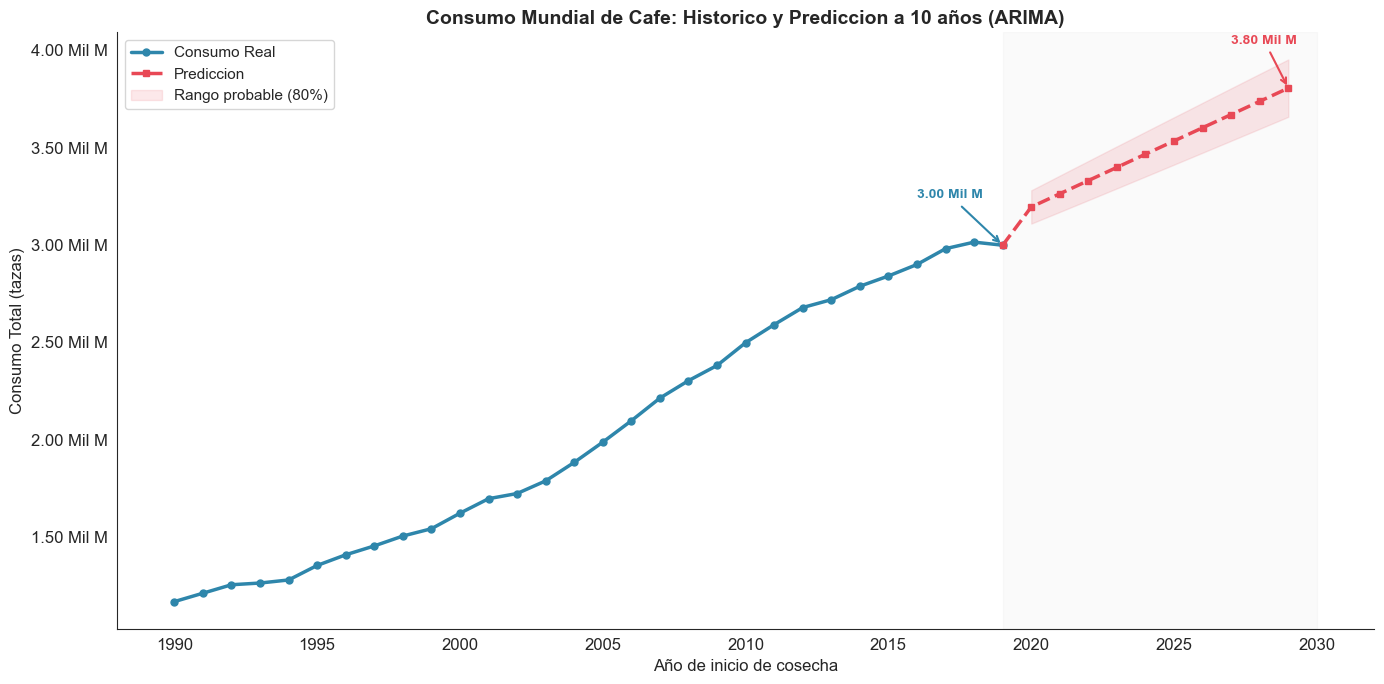


RESUMEN DE LA PREDICCION MUNDIAL:
   Ultimo dato real (cosecha 2019/20):  3.00 Mil M tazas
   Prediccion (cosecha 2029/30):    3.80 Mil M tazas
   Rango probable:  3.66 — 3.95 Mil M tazas
   Cambio esperado: +26.9%


In [151]:
# ============================================================
# 6.1.2 — VISUALIZACION DE LA PREDICCION MUNDIAL
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

# Datos reales
ax.plot(consumo_mundial_ts.index, consumo_mundial_ts.values, 
        color='#2E86AB', linewidth=2.5, marker='o', markersize=5, 
        label='Consumo Real')

# Prediccion conectada desde el ultimo punto real
años_futuro = forecast_series[forecast_series.index > 2019]
pred_conectada_x = [2019] + list(años_futuro.index)
pred_conectada_y = [consumo_mundial_ts.iloc[-1]] + list(años_futuro.values)

ax.plot(pred_conectada_x, pred_conectada_y, 
        color='#E84855', linewidth=2.5, linestyle='--', marker='s', markersize=5,
        label='Prediccion')

# Intervalo de confianza
ci_futuro = forecast_ci.iloc[n_test:]
ax.fill_between(años_futuro.index, 
                ci_futuro.iloc[:, 0].values, ci_futuro.iloc[:, 1].values,
                color='#E84855', alpha=0.12, label='Rango probable (80%)')

# Zona de prediccion
ax.axvspan(2019, 2030, alpha=0.04, color='gray')

# Anotaciones
ax.annotate(f'{consumo_mundial_ts.iloc[-1]/1e9:.2f} Mil M', 
            xy=(2019, consumo_mundial_ts.iloc[-1]),
            xytext=(2016, consumo_mundial_ts.iloc[-1] * 1.08),
            fontsize=10, fontweight='bold', color='#2E86AB',
            arrowprops=dict(arrowstyle='->', color='#2E86AB', lw=1.5))

ax.annotate(f'{años_futuro.iloc[-1]/1e9:.2f} Mil M', 
            xy=(años_futuro.index[-1], años_futuro.iloc[-1]),
            xytext=(años_futuro.index[-1] - 2, años_futuro.iloc[-1] * 1.06),
            fontsize=10, fontweight='bold', color='#E84855',
            arrowprops=dict(arrowstyle='->', color='#E84855', lw=1.5))

ax.set_xlabel('Año de inicio de cosecha')
ax.set_ylabel('Consumo Total (tazas)')
ax.set_title('Consumo Mundial de Cafe: Historico y Prediccion a 10 años (ARIMA)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e9:.2f} Mil M'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Resumen numerico
ultimo_real = consumo_mundial_ts.iloc[-1]
ultimo_pred = años_futuro.iloc[-1]
año_pred = años_futuro.index[-1]
rango_bajo = ci_futuro.iloc[-1, 0]
rango_alto = ci_futuro.iloc[-1, 1]
cambio = ((ultimo_pred - ultimo_real) / ultimo_real) * 100

print(f"\nRESUMEN DE LA PREDICCION MUNDIAL:")
print(f"   Ultimo dato real (cosecha 2019/20):  {ultimo_real/1e9:.2f} Mil M tazas")
print(f"   Prediccion (cosecha {año_pred}/{año_pred-2000+1}):    {ultimo_pred/1e9:.2f} Mil M tazas")
print(f"   Rango probable:  {rango_bajo/1e9:.2f} — {rango_alto/1e9:.2f} Mil M tazas")
print(f"   Cambio esperado: {cambio:+.1f}%")

### 6.1.3 — Prediccion por Top 5 Paises

Se aplica el mismo modelo ARIMA a cada uno de los 5 mayores consumidores para saber si van a seguir creciendo o no. Los resultados se presentan en una tabla comparativa.

In [152]:
# ============================================================
# 6.1.3 — PREDICCION POR TOP 5 PAISES
# ============================================================

top5_paises = consumo_por_pais.head(5)['Pais'].tolist()

resultados_forecast = {}
metricas_paises = []
predicciones_resumen = []

for pais in top5_paises:
    df_pais = df_consumo_pais[df_consumo_pais['Pais'] == pais].dropna(subset=['Consumo_Anual_Domestico'])
    serie_pais = df_pais.set_index('Año_Inicio')['Consumo_Anual_Domestico'].sort_index()
    
    train_p = serie_pais[serie_pais.index <= 2014]
    test_p = serie_pais[serie_pais.index > 2014]
    
    modelo = ARIMA(train_p, order=(2, 1, 1))
    modelo_fit = modelo.fit()
    
    n_test_p = len(test_p)
    forecast_p = modelo_fit.get_forecast(steps=n_test_p + 10)
    pred_values = forecast_p.predicted_mean
    pred_ci = forecast_p.conf_int(alpha=0.2)
    pred_index = list(range(2015, 2015 + n_test_p + 10))
    pred_series = pd.Series(pred_values.values, index=pred_index)
    
    pred_test_p = pred_series[:n_test_p]
    mape_p = np.mean(np.abs((test_p.values - pred_test_p.values) / test_p.values)) * 100
    
    metricas_paises.append({'Pais': pais, 'MAPE': mape_p})
    resultados_forecast[pais] = {
        'serie': serie_pais,
        'prediccion': pred_series,
        'ci': pred_ci,
        'n_test': n_test_p
    }
    
    ultimo_real = serie_pais.iloc[-1]
    pred_2029 = pred_series[2029]
    ci_2029_bajo = pred_ci.iloc[-1, 0]
    ci_2029_alto = pred_ci.iloc[-1, 1]
    cambio = ((pred_2029 - ultimo_real) / ultimo_real) * 100
    
    predicciones_resumen.append({
        'Pais': pais,
        'Ultimo Real (2019/20)': f'{ultimo_real/1e6:,.0f}M',
        'Prediccion (2029/30)': f'{pred_2029/1e6:,.0f}M',
        'Rango Bajo': f'{ci_2029_bajo/1e6:,.0f}M',
        'Rango Alto': f'{ci_2029_alto/1e6:,.0f}M',
        'Cambio Esperado': f'{cambio:+.1f}%',
        'MAPE': f'{mape_p:.1f}%'
    })

# TABLA RESUMEN
df_resumen = pd.DataFrame(predicciones_resumen)
print("TABLA DE PREDICCIONES — Top 5 Consumidores")
print("=" * 105)
print(f"{'Pais':<15} {'Real 2019/20':>14} {'Pred 2029/30':>14} {'Rango Bajo':>12} {'Rango Alto':>12} {'Cambio':>10} {'MAPE':>8}")
print("-" * 105)
for _, row in df_resumen.iterrows():
    print(f"{row['Pais']:<15} {row['Ultimo Real (2019/20)']:>14} {row['Prediccion (2029/30)']:>14} {row['Rango Bajo']:>12} {row['Rango Alto']:>12} {row['Cambio Esperado']:>10} {row['MAPE']:>8}")
print("-" * 105)
print("\nMAPE = Error promedio del modelo. Menor es mejor.")
print("Rango = Intervalo donde probablemente caera el consumo real (80% de confianza)")

TABLA DE PREDICCIONES — Top 5 Consumidores
Pais              Real 2019/20   Pred 2029/30   Rango Bajo   Rango Alto     Cambio     MAPE
---------------------------------------------------------------------------------------------------------
Brazil                  1,320M         1,662M       1,563M       1,761M     +25.9%     1.4%
Indonesia                 288M           268M         196M         339M      -7.2%     5.3%
Ethiopia                  227M           290M         283M         297M     +27.8%     2.1%
Mexico                    146M           141M         112M         169M      -3.3%     2.2%
Philippines               195M           218M         142M         295M     +12.0%     2.0%
---------------------------------------------------------------------------------------------------------

MAPE = Error promedio del modelo. Menor es mejor.
Rango = Intervalo donde probablemente caera el consumo real (80% de confianza)


## 6.2 — Segmentacion de Mercados (K-Means Clustering)

La prediccion nos dice **cuanto** va a consumir cada pais. Ahora es necesario entender **como se comportan** los paises para agruparlos en segmentos de mercado.

**¿Para que sirve esto?** High Garden Coffee no puede tener una estrategia diferente para cada uno de los 53 paises. Pero si se agrupan los paises en 3 o 4 grupos con comportamiento similar, la empresa puede diseñar una estrategia por grupo.

**K-Means** es un algoritmo que agrupa datos en K grupos (clusters) basandose en similitud. Cada pais se describe con variables numericas y el algoritmo encuentra los grupos que minimizan las diferencias dentro de cada grupo.

**Variables que usamos para agrupar:**
- Consumo promedio anual (tamaño del mercado)
- CAGR (si esta creciendo o cayendo)
- Volatilidad del consumo (que tan estable es)

In [153]:
# ============================================================
# 6.2.1 — PREPARAR VARIABLES PARA CLUSTERING
# ============================================================

# Calcular variables por pais
features_pais = []

for _, row in df_clean.iterrows():
    pais = row['Country']
    tipo = row['Coffee type']
    valores = row[year_columns].values.astype(float)
    valid = valores[~np.isnan(valores)]
    
    if len(valid) >= 5:
        consumo_promedio = np.mean(valid)
        
        inicio = valid[0]
        fin = valid[-1]
        n = len(valid) - 1
        cagr = ((fin / inicio) ** (1 / n) - 1) * 100 if inicio > 0 else 0
        
        volatilidad = (np.std(valid) / np.mean(valid)) * 100
        
        features_pais.append({
            'Pais': pais,
            'Tipo_Cafe': tipo,
            'Consumo_Promedio': consumo_promedio,
            'CAGR': cagr,
            'Volatilidad': volatilidad
        })

df_features = pd.DataFrame(features_pais)

# Aplica logaritmo al consumo para reducir el efecto de paises gigantes como Brasil
# Sin esto, Brasil domina el clustering y todos los demas quedan en un solo grupo
df_features['Log_Consumo'] = np.log10(df_features['Consumo_Promedio'])

print(f"Paises con datos suficientes para clustering: {len(df_features)}")

Paises con datos suficientes para clustering: 53


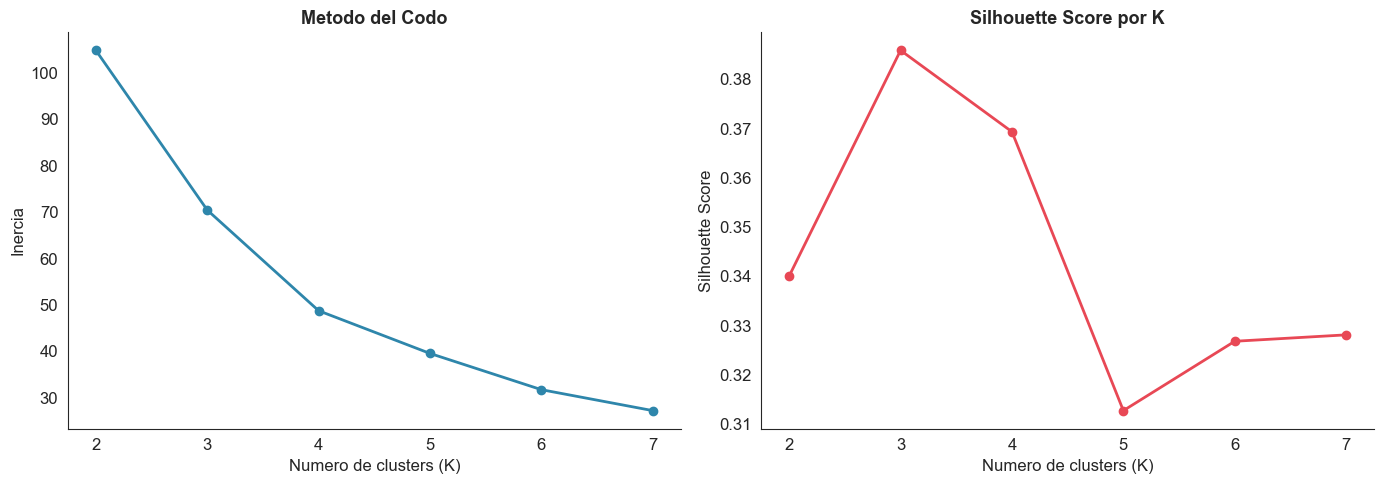


Mejor K segun Silhouette Score: 3
Silhouette Score: 0.386


In [154]:
# ============================================================
# 6.2.2 — ENCONTRAR EL NUMERO OPTIMO DE CLUSTERS
# ============================================================

# Estandarizar usando Log_Consumo en vez de Consumo_Promedio
scaler = StandardScaler()
X = scaler.fit_transform(df_features[['Log_Consumo', 'CAGR', 'Volatilidad']])

# Metodo del codo y Silhouette Score
inertias = []
silhouettes = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, marker='o', linewidth=2, color='#2E86AB')
ax1.set_xlabel('Numero de clusters (K)')
ax1.set_ylabel('Inercia')
ax1.set_title('Metodo del Codo', fontsize=13, fontweight='bold')

ax2.plot(K_range, silhouettes, marker='o', linewidth=2, color='#E84855')
ax2.set_xlabel('Numero de clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por K', fontsize=13, fontweight='bold')

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

mejor_k = list(K_range)[np.argmax(silhouettes)]
print(f"\nMejor K segun Silhouette Score: {mejor_k}")
print(f"Silhouette Score: {max(silhouettes):.3f}")

In [155]:
# ============================================================
# 6.2.3 — APLICAR CLUSTERING CON EL K OPTIMO
# ============================================================

kmeans_final = KMeans(n_clusters=mejor_k, random_state=42, n_init=10)
df_features['Cluster'] = kmeans_final.fit_predict(X)

# Analizar cada cluster
print("PERFIL DE CADA SEGMENTO DE MERCADO")
print("=" * 80)

for cluster in sorted(df_features['Cluster'].unique()):
    grupo = df_features[df_features['Cluster'] == cluster]
    print(f"\nSegmento {cluster + 1} ({len(grupo)} paises):")
    print(f"   Consumo promedio: {grupo['Consumo_Promedio'].mean()/1e6:,.1f}M tazas/año")
    print(f"   CAGR promedio:    {grupo['CAGR'].mean():.1f}%")
    print(f"   Volatilidad:      {grupo['Volatilidad'].mean():.1f}%")
    print(f"   Paises: {', '.join(grupo['Pais'].tolist())}")

PERFIL DE CADA SEGMENTO DE MERCADO

Segmento 1 (35 paises):
   Consumo promedio: 16.2M tazas/año
   CAGR promedio:    0.5%
   Volatilidad:      16.8%
   Paises: Angola, Bolivia (Plurinational State of), Burundi, Ecuador, Madagascar, Papua New Guinea, Paraguay, Peru, Timor-Leste, Congo, Cuba, Dominican Republic, Haiti, Cameroon, Colombia, Costa Rica, Democratic Republic of Congo, El Salvador, Guatemala, Guinea, Guyana, Honduras, India, Jamaica, Kenya, Lao People's Democratic Republic, Liberia, Mexico, Nigeria, Panama, Sierra Leone, Sri Lanka, Trinidad & Tobago, Venezuela, Yemen

Segmento 2 (10 paises):
   Consumo promedio: 147.8M tazas/año
   CAGR promedio:    6.4%
   Volatilidad:      50.1%
   Paises: Brazil, Indonesia, Philippines, Tanzania, Côte d'Ivoire, Ethiopia, Nicaragua, Thailand, Uganda, Viet Nam

Segmento 3 (8 paises):
   Consumo promedio: 0.2M tazas/año
   CAGR promedio:    -3.0%
   Volatilidad:      59.9%
   Paises: Malawi, Rwanda, Zimbabwe, Zambia, Central African Republic,

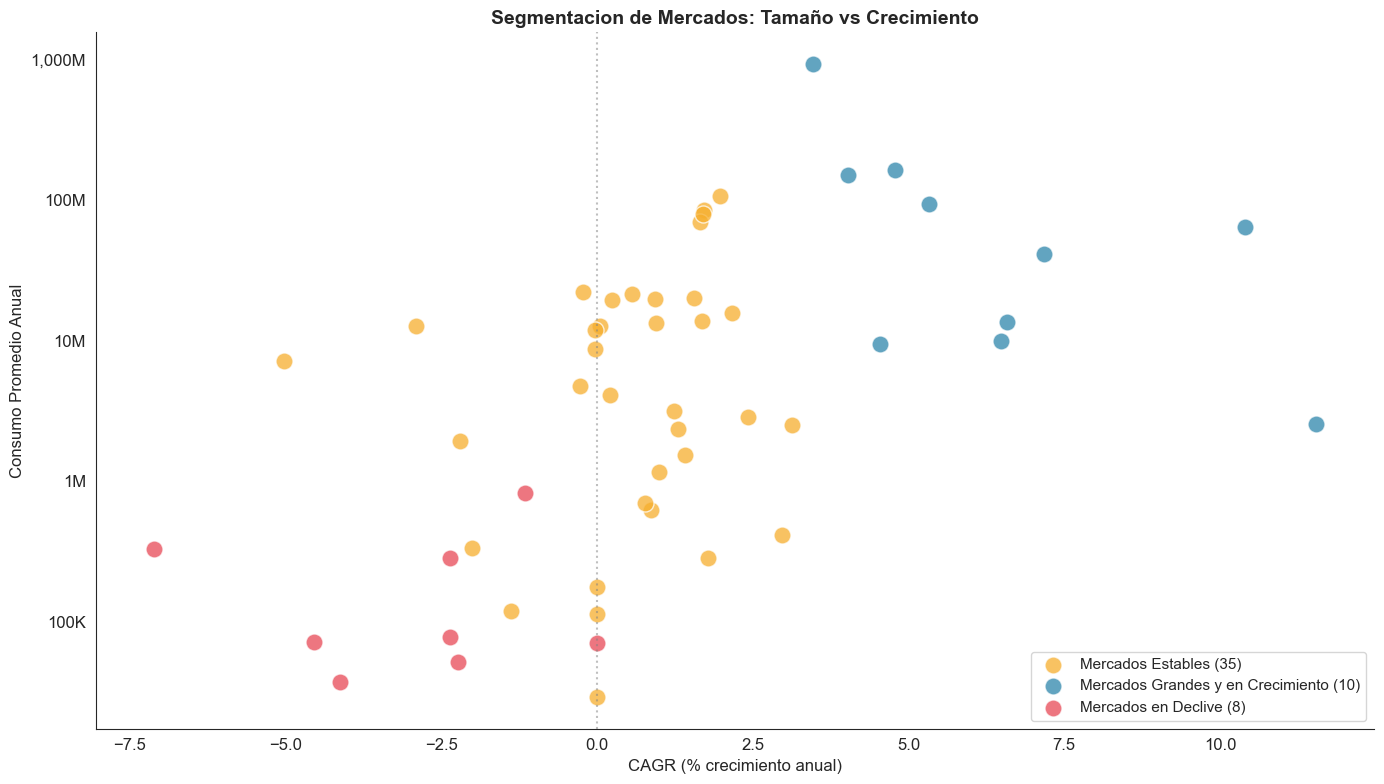

In [156]:
# ============================================================
# 6.2.4 — VISUALIZACION DE LOS CLUSTERS
# ============================================================

# Nombres descriptivos para los clusters
cluster_profiles = df_features.groupby('Cluster').agg(
    Consumo_Medio=('Consumo_Promedio', 'mean'),
    CAGR_Medio=('CAGR', 'mean'),
    Volatilidad_Media=('Volatilidad', 'mean'),
    N_Paises=('Pais', 'count')
).reset_index()

nombres_cluster = {}
for _, row in cluster_profiles.iterrows():
    c = row['Cluster']
    if row['Consumo_Medio'] > cluster_profiles['Consumo_Medio'].median() and row['CAGR_Medio'] > 0:
        nombres_cluster[c] = 'Mercados Grandes y en Crecimiento'
    elif row['CAGR_Medio'] > cluster_profiles['CAGR_Medio'].median():
        nombres_cluster[c] = 'Mercados Emergentes'
    elif row['CAGR_Medio'] < 0:
        nombres_cluster[c] = 'Mercados en Declive'
    else:
        nombres_cluster[c] = 'Mercados Estables'

df_features['Segmento'] = df_features['Cluster'].map(nombres_cluster)

# Colores por segmento
colores_segmento = {
    'Mercados Grandes y en Crecimiento': '#2E86AB',
    'Mercados Emergentes': '#33A474',
    'Mercados Estables': '#F6AE2D',
    'Mercados en Declive': '#E84855'
}

# Grafico
fig, ax = plt.subplots(figsize=(14, 8))

for segmento in df_features['Segmento'].unique():
    grupo = df_features[df_features['Segmento'] == segmento]
    color = colores_segmento.get(segmento, 'gray')
    ax.scatter(grupo['CAGR'], grupo['Log_Consumo'], 
              color=color, s=150, alpha=0.75,
              label=f'{segmento} ({len(grupo)})', 
              edgecolors='white', linewidth=1)

ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('CAGR (% crecimiento anual)', fontsize=12)
ax.set_ylabel('Consumo Promedio Anual', fontsize=12)
ax.set_title('Segmentacion de Mercados: Tamaño vs Crecimiento', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

y_ticks = [5, 6, 7, 8, 9]
y_labels = ['100K', '1M', '10M', '100M', '1,000M']
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels)

plt.tight_layout()
plt.show()

## 6.3 — Proyeccion de Rangos de Precios Futuros

El dataset original no contiene precios, por lo que se tomaron los datos con precios historicos del FMI (Arabica y Robusta en USD por libra).

Se aplicaron dos enfoques complementarios:

1. **ARIMA sobre precios historicos:** el mismo modelo que usamos para consumo, ahora aplicado a los precios.
2. **Escenarios ajustados por demanda:** si el consumo (demanda) crece, hay presion para que los precios suban. Generamos 3 escenarios: pesimista, base y optimista.

Los resultados son **rangos**, no valores exactos, porque los precios dependen de factores que no estan en los datos (clima, politicas comerciales, especulacion).

In [157]:
# ============================================================
# 6.3.1 — MODELO ARIMA PARA PRECIOS
# ============================================================

serie_arabica = df_arabica[df_arabica['Año'] <= 2020].set_index('Año')['Precio_Arabica_USD_por_libra']
serie_robusta = df_robusta[df_robusta['Año'] <= 2020].set_index('Año')['Precio_Robusta_USD_por_libra']

resultados_precios = {}

for nombre, serie in [('Arabica', serie_arabica), ('Robusta', serie_robusta)]:
    train = serie[serie.index <= 2015]
    test = serie[serie.index > 2015]
    
    modelo = ARIMA(train, order=(2, 1, 1))
    modelo_fit = modelo.fit()
    
    n_test = len(test)
    forecast = modelo_fit.get_forecast(steps=n_test + 10)
    pred_values = forecast.predicted_mean
    pred_ci = forecast.conf_int(alpha=0.2)
    pred_index = list(range(2016, 2016 + n_test + 10))
    pred_series = pd.Series(pred_values.values, index=pred_index)
    
    pred_test = pred_series[:n_test]
    test_values = test.values[:n_test]
    mape = np.mean(np.abs((test_values - pred_test.values) / test_values)) * 100
    
    resultados_precios[nombre] = {
        'serie': serie,
        'prediccion': pred_series,
        'ci': pred_ci,
        'n_test': n_test,
        'mape': mape
    }
    
    print(f"{nombre}:")
    print(f"   MAPE: {mape:.1f}%")
    print(f"   Ultimo precio real (2020): ${serie.iloc[-1]:.2f} USD/lb")
    print(f"   Prediccion 2030: ${pred_series[2030]:.2f} USD/lb")
    print(f"   Rango 2030: ${pred_ci.iloc[-1, 0]:.2f} — ${pred_ci.iloc[-1, 1]:.2f} USD/lb")
    print()

Arabica:
   MAPE: 14.7%
   Ultimo precio real (2020): $1.51 USD/lb
   Prediccion 2030: $1.59 USD/lb
   Rango 2030: $0.09 — $3.10 USD/lb

Robusta:
   MAPE: 12.8%
   Ultimo precio real (2020): $0.69 USD/lb
   Prediccion 2030: $0.81 USD/lb
   Rango 2030: $-0.12 — $1.75 USD/lb



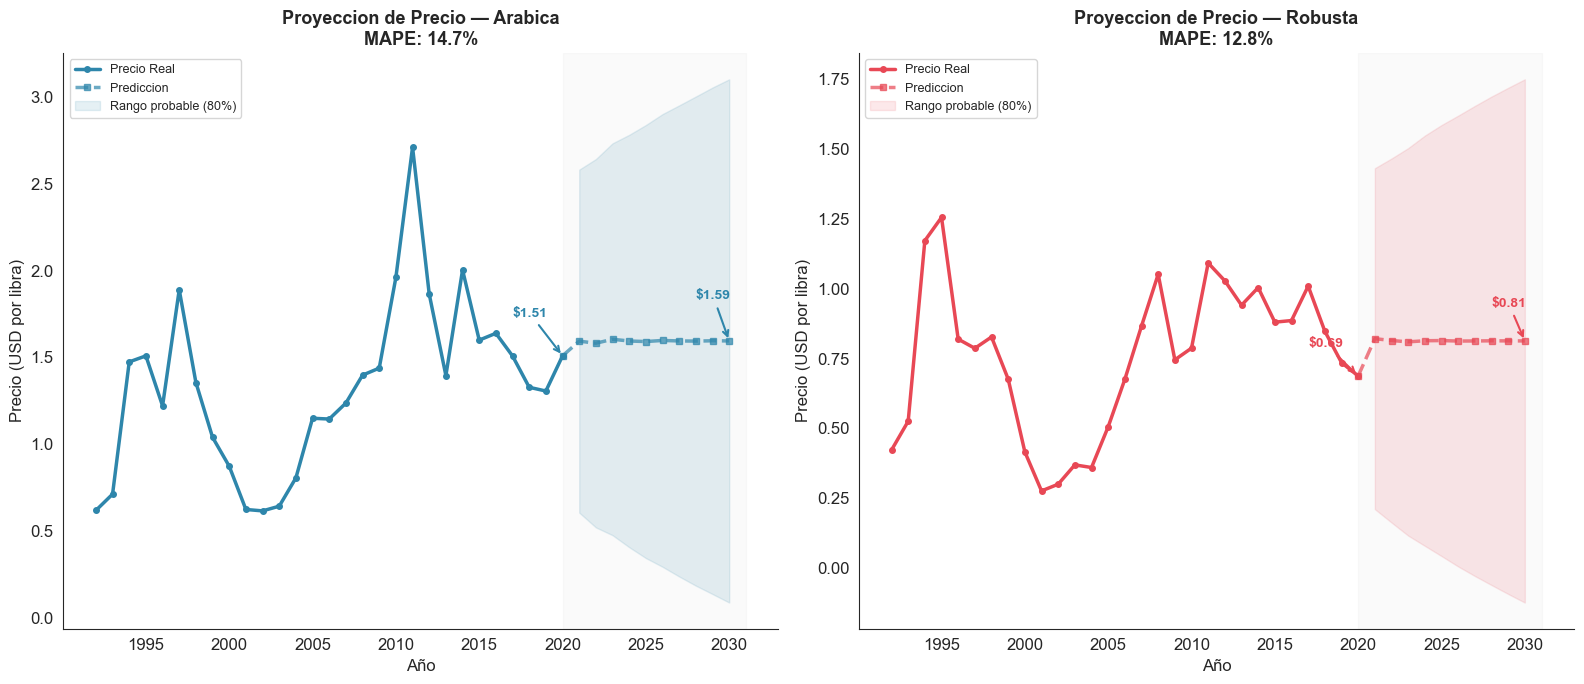

In [158]:
# ============================================================
# 6.3.2 — VISUALIZACION DE PROYECCION DE PRECIOS
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, nombre, color in [(ax1, 'Arabica', '#2E86AB'), (ax2, 'Robusta', '#E84855')]:
    data = resultados_precios[nombre]
    serie = data['serie']
    pred = data['prediccion']
    ci = data['ci']
    n_test = data['n_test']
    
    ax.plot(serie.index, serie.values, color=color, linewidth=2.5, 
            marker='o', markersize=4, label='Precio Real')
    
    fut = pred[pred.index > 2020]
    pred_conectada_x = [2020] + list(fut.index)
    pred_conectada_y = [serie.iloc[-1]] + list(fut.values)
    ax.plot(pred_conectada_x, pred_conectada_y, color=color, linewidth=2.5, 
            linestyle='--', marker='s', markersize=4, label='Prediccion', alpha=0.7)
    
    ci_fut = ci.iloc[n_test:]
    ax.fill_between(fut.index, ci_fut.iloc[:, 0].values, ci_fut.iloc[:, 1].values,
                    color=color, alpha=0.12, label='Rango probable (80%)')
    
    ax.axvspan(2020, 2031, alpha=0.04, color='gray')
    
    ax.annotate(f'${serie.iloc[-1]:.2f}', 
                xy=(2020, serie.iloc[-1]),
                xytext=(2017, serie.iloc[-1] * 1.15),
                fontsize=10, fontweight='bold', color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    
    ax.annotate(f'${fut.iloc[-1]:.2f}', 
                xy=(fut.index[-1], fut.iloc[-1]),
                xytext=(fut.index[-1] - 2, fut.iloc[-1] * 1.15),
                fontsize=10, fontweight='bold', color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    
    ax.set_xlabel('Año')
    ax.set_ylabel('Precio (USD por libra)')
    ax.set_title(f'Proyeccion de Precio — {nombre}\nMAPE: {data["mape"]:.1f}%', 
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [159]:
# ============================================================
# 6.3.3 — TABLA RESUMEN DE PROYECCION DE PRECIOS
# ============================================================

print("PROYECCION DE RANGOS DE PRECIOS — CAFE VERDE (USD por libra)")
print("=" * 85)
print(f"{'Tipo':<12} {'Real 2020':>12} {'Pred 2030':>12} {'Rango Bajo':>12} {'Rango Alto':>12} {'Cambio':>10} {'MAPE':>8}")
print("-" * 85)

for nombre in ['Arabica', 'Robusta']:
    data = resultados_precios[nombre]
    serie = data['serie']
    pred = data['prediccion']
    ci = data['ci']
    
    real = serie.iloc[-1]
    pred_val = pred[2030]
    bajo = ci.iloc[-1, 0]
    alto = ci.iloc[-1, 1]
    cambio = ((pred_val - real) / real) * 100
    
    print(f"{nombre:<12} ${real:>10.2f} ${pred_val:>10.2f} ${bajo:>10.2f} ${alto:>10.2f} {cambio:>+9.1f}% {data['mape']:>6.1f}%")

print("-" * 85)

spread_actual = serie_arabica.iloc[-1] - serie_robusta.iloc[-1]
spread_futuro = resultados_precios['Arabica']['prediccion'][2030] - resultados_precios['Robusta']['prediccion'][2030]
cambio_spread = ((spread_futuro - spread_actual) / spread_actual) * 100

print(f"\nDiferencia de precio Arabica vs Robusta:")
print(f"   2020: ${spread_actual:.2f}/lb  |  2030: ${spread_futuro:.2f}/lb  ({cambio_spread:+.1f}%)")
if spread_futuro < spread_actual:
    print(f"   Robusta se encarece mas rapido que Arabica, la diferencia de precio se achica")
else:
    print(f"   Arabica se encarece mas rapido, la brecha de precio se amplia")

PROYECCION DE RANGOS DE PRECIOS — CAFE VERDE (USD por libra)
Tipo            Real 2020    Pred 2030   Rango Bajo   Rango Alto     Cambio     MAPE
-------------------------------------------------------------------------------------
Arabica      $      1.51 $      1.59 $      0.09 $      3.10      +5.7%   14.7%
Robusta      $      0.69 $      0.81 $     -0.12 $      1.75     +18.3%   12.8%
-------------------------------------------------------------------------------------

Diferencia de precio Arabica vs Robusta:
   2020: $0.82/lb  |  2030: $0.78/lb  (-4.8%)
   Robusta se encarece mas rapido que Arabica, la diferencia de precio se achica


In [160]:
# ============================================================
# 6.3.4 — INTEGRACION CONSUMO-PRECIO: ESCENARIOS
# ============================================================

consumo_real_2019 = consumo_mundial.iloc[-1]['Consumo_Total']
consumo_pred_2029 = forecast_series[2029]
crecimiento_consumo = ((consumo_pred_2029 - consumo_real_2019) / consumo_real_2019) * 100

print("ESCENARIOS DE PRECIO AJUSTADOS POR DEMANDA")
print("=" * 85)
print(f"\nCrecimiento esperado del consumo mundial: {crecimiento_consumo:.1f}%")
print(f"Correlacion consumo-precio Arabica: {corr_arabica:.2f}")
print(f"Correlacion consumo-precio Robusta: {corr_robusta:.2f}")

print(f"\n{'Escenario':<20} {'Arabica (USD/lb)':>20} {'Robusta (USD/lb)':>20}")
print("-" * 65)

for nombre_esc, factor in [('Pesimista', 0.85), ('Base', 1.0), ('Optimista', 1.15)]:
    precio_a = resultados_precios['Arabica']['prediccion'][2030] * factor
    precio_r = resultados_precios['Robusta']['prediccion'][2030] * factor
    print(f"{nombre_esc:<20} ${precio_a:>18.2f} ${precio_r:>18.2f}")

print("-" * 65)
print(f"\nInterpretacion:")
print(f"   Pesimista: caida de demanda o sobreproduccion (precios -15%)")
print(f"   Base: tendencia actual se mantiene")
print(f"   Optimista: crecimiento de demanda acelera (precios +15%)")
print(f"\n   Estos rangos permiten a High Garden Coffee planificar sus")
print(f"   contratos de exportacion con margenes de seguridad")

ESCENARIOS DE PRECIO AJUSTADOS POR DEMANDA

Crecimiento esperado del consumo mundial: 26.9%
Correlacion consumo-precio Arabica: 0.51
Correlacion consumo-precio Robusta: 0.36

Escenario                Arabica (USD/lb)     Robusta (USD/lb)
-----------------------------------------------------------------
Pesimista            $              1.36 $              0.69
Base                 $              1.59 $              0.81
Optimista            $              1.83 $              0.94
-----------------------------------------------------------------

Interpretacion:
   Pesimista: caida de demanda o sobreproduccion (precios -15%)
   Base: tendencia actual se mantiene
   Optimista: crecimiento de demanda acelera (precios +15%)

   Estos rangos permiten a High Garden Coffee planificar sus
   contratos de exportacion con margenes de seguridad


## 7. Conclusiones y Recomendaciones Estrategicas

A partir del analisis exploratorio, los modelos de prediccion y la segmentacion de mercados, se presentan las conclusiones y recomendaciones para High Garden Coffee.

In [161]:
print("RESUMEN — HIGH GARDEN COFFEE")
print("=" * 80)

# 1. Mercado global
consumo_inicio = consumo_mundial.iloc[0]['Consumo_Total']
consumo_fin = consumo_mundial.iloc[-1]['Consumo_Total']
cagr_global = ((consumo_fin / consumo_inicio) ** (1 / (len(consumo_mundial)-1)) - 1) * 100
consumo_pred = forecast_series[2029]
cambio_pred = ((consumo_pred - consumo_fin) / consumo_fin) * 100

print(f"\n1. MERCADO GLOBAL")
print(f"   El consumo mundial de cafe crecio de {consumo_inicio/1e9:.2f} a {consumo_fin/1e9:.2f}")
print(f"   mil millones de tazas en 30 cosechas (CAGR: {cagr_global:.1f}% anual)")
print(f"   Prediccion a 10 años: {consumo_pred/1e9:.2f} mil millones ({cambio_pred:+.1f}%)")
print(f"   El mercado sigue en expansion.")

# 2. Concentracion
print(f"\n2. CONCENTRACION DE MERCADO")
top5_pct = consumo_por_pais.head(5)['Porcentaje'].sum()
print(f"   Los 5 mayores consumidores concentran el {top5_pct:.1f}% del mercado")
print(f"   {consumo_por_pais.iloc[0]['Pais']} lidera con {consumo_por_pais.iloc[0]['Porcentaje']:.1f}%")
print(f"   Alta concentracion implica riesgo: una caida en Brasil")
print(f"   impactaria significativamente la demanda global.")

# 3. Segmentos
print(f"\n3. SEGMENTOS DE MERCADO (Clustering K-Means)")
for cluster in sorted(df_features['Cluster'].unique()):
    grupo = df_features[df_features['Cluster'] == cluster]
    nombre = nombres_cluster[cluster]
    print(f"   {nombre}: {len(grupo)} paises")
    print(f"      Consumo promedio: {grupo['Consumo_Promedio'].mean()/1e6:,.1f}M tazas/año")
    print(f"      Crecimiento: {grupo['CAGR'].mean():.1f}% anual")

# 4. Precios
print(f"\n4. PROYECCION DE PRECIOS")
for nombre in ['Arabica', 'Robusta']:
    data = resultados_precios[nombre]
    real = data['serie'].iloc[-1]
    pred = data['prediccion'][2030]
    cambio = ((pred - real) / real) * 100
    print(f"   {nombre}: ${real:.2f} (2020) -> ${pred:.2f} (2030) | {cambio:+.1f}%")

RESUMEN — HIGH GARDEN COFFEE

1. MERCADO GLOBAL
   El consumo mundial de cafe crecio de 1.17 a 3.00
   mil millones de tazas en 30 cosechas (CAGR: 3.3% anual)
   Prediccion a 10 años: 3.80 mil millones (+26.9%)
   El mercado sigue en expansion.

2. CONCENTRACION DE MERCADO
   Los 5 mayores consumidores concentran el 70.7% del mercado
   Brazil lidera con 45.5%
   Alta concentracion implica riesgo: una caida en Brasil
   impactaria significativamente la demanda global.

3. SEGMENTOS DE MERCADO (Clustering K-Means)
   Mercados Estables: 35 paises
      Consumo promedio: 16.2M tazas/año
      Crecimiento: 0.5% anual
   Mercados Grandes y en Crecimiento: 10 paises
      Consumo promedio: 147.8M tazas/año
      Crecimiento: 6.4% anual
   Mercados en Declive: 8 paises
      Consumo promedio: 0.2M tazas/año
      Crecimiento: -3.0% anual

4. PROYECCION DE PRECIOS
   Arabica: $1.51 (2020) -> $1.59 (2030) | +5.7%
   Robusta: $0.69 (2020) -> $0.81 (2030) | +18.3%


### 7.2 — Recomendaciones Estrategicas

**1. Diversificar mercados de destino**

El mercado esta muy concentrado en pocos paises. Se recomienda expandir operaciones hacia mercados emergentes como Tanzania (CAGR 11.5%), Vietnam (10.4%) y Filipinas (5.3%) que muestran crecimiento sostenido.

**2. Priorizar cafe tipo Arabica/Robusta (mezcla)**

Este tipo representa el 51% del consumo mundial y mantiene tendencia de crecimiento. Las mezclas dominan el mercado y es donde esta la mayor demanda.

**3. Reducir exposicion a mercados en declive**

Paises como Ghana (CAGR -7.1%), Yemen (-5.0%) y Togo (-4.5%) muestran caida consistente. Reasignar recursos de estos mercados hacia los emergentes.

**4. Estrategia de precios por escenario**

Los precios de ambos tipos de cafe muestran tendencia alcista. Se recomienda negociar contratos de exportacion a mediano plazo usando los rangos proyectados como referencia para establecer pisos y techos de precio.

**5. Monitorear la diferencia de precio Arabica vs Robusta**

La diferencia de precio entre ambos tipos se esta reduciendo. Si esta tendencia continua, el Robusta gana competitividad en precio, lo cual podria cambiar las preferencias de compra de algunos mercados.

## 8. Bonus: Propuesta de Integracion con IA Generativa

### Objetivo

Permitir que cualquier persona de High Garden Coffee pueda consultar los resultados del analisis haciendo preguntas en lenguaje natural, sin necesidad de abrir el notebook ni saber Python.

### Arquitectura

La solucion se compone de tres partes:

1. **Datos:** los datasets procesados (consumo por pais, precios, predicciones ARIMA, segmentos de clustering) se cargan en memoria al iniciar la aplicacion
2. **Modelo de lenguaje:** se utiliza la API gratuita de Google Gemini. El modelo recibe como contexto un resumen estructurado de todos los hallazgos y metricas del analisis, y responde las preguntas del usuario basandose en esa informacion
3. **Interfaz:** aplicacion web construida con Streamlit que integra un chat interactivo junto con las visualizaciones principales del analisis

### Flujo de funcionamiento

1. El usuario abre la aplicacion en su navegador
2. Escribe una pregunta, por ejemplo: "Que mercados deberia priorizar en Asia?"
3. La aplicacion construye un prompt que incluye la pregunta + el contexto de los datos
4. Gemini procesa la pregunta y devuelve una respuesta fundamentada en los datos reales
5. La respuesta se muestra en el chat

### Ejemplos de consultas

- "Cuales son los 3 mercados con mayor potencial de crecimiento?"
- "Que precio de Arabica podemos esperar en 2030?"
- "En que segmento esta Colombia y que estrategia se recomienda?"
- "Dame un resumen ejecutivo para presentar al directorio"

### Tecnologias

- **Streamlit:** framework de Python para crear aplicaciones web de datos
- **Google Gemini API:** modelo de lenguaje gratuito para el chatbot
- **Plotly:** graficos interactivos dentro de la aplicacion

### Implementacion

Esta propuesta se implementa como una aplicacion funcional en el archivo `app_streamlit/app.py` que acompaña este notebook.